# 3. Projekat iz predmeta **Mašinsko učenje**
**Dataset:**  
[Sleep Patterns vs Daily Performance](https://www.kaggle.com/datasets/arsalanjamal002/sleep-patterns-vs-daily-performance)

## Setup i učitavanje
### Import biblioteka i setovanje konstantni

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

!pip install tensorflow

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

### Učitavanje podataka i pregled strukture

In [2]:
dataset = pd.read_csv('Sleep_Patterns_vs_Daily_Performance.csv')

dataset.info()
dataset.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Sleep_Hours              30000 non-null  float64
 1   Sleep_Quality_Score      30000 non-null  int64  
 2   Caffeine_Intake_mg       30000 non-null  float64
 3   Screen_Time_Before_Bed   30000 non-null  float64
 4   Morning_Mood             30000 non-null  object 
 5   Work_Productivity_Score  30000 non-null  int64  
 6   Error_Rate               30000 non-null  float64
 7   Energy_Level             30000 non-null  int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 1.8+ MB


,Sleep_Hours,Sleep_Quality_Score,Caffeine_Intake_mg,Screen_Time_Before_Bed,Work_Productivity_Score,Error_Rate,Energy_Level
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,6.987010,7.590433,198.492067,58.685500,73.637667,6.499266,8.656567
std,1.468244,1.518826,133.939111,54.993704,13.119905,3.785921,1.330669
min,2.000000,1.000000,1.000000,0.000000,6.000000,0.000000,1.000000
25%,6.000000,7.000000,97.000000,17.000000,66.000000,3.757500,8.000000
50%,7.000000,8.000000,169.000000,42.000000,75.000000,6.140000,9.000000
75%,8.000000,9.000000,271.000000,84.000000,83.000000,8.890000,10.000000
max,10.000000,10.000000,600.000000,240.000000,100.000000,26.900000,10.000000


In [3]:
dataset.head()

,Sleep_Hours,Sleep_Quality_Score,Caffeine_Intake_mg,Screen_Time_Before_Bed,Morning_Mood,Work_Productivity_Score,Error_Rate,Energy_Level
0,7.7,7,498.0,107.0,Neutral,71,10.45,8
1,6.8,8,315.0,128.0,Good,80,6.49,10
2,8.0,10,412.0,34.0,Excellent,85,3.88,10
3,9.3,9,447.0,28.0,Good,85,3.18,10
4,6.6,7,177.0,57.0,Neutral,70,6.74,8


## Preprocesiranje podataka

### Uklanjanje duplikata

In [4]:
broj_duplikata = dataset.duplicated().sum()
print(f'Broj duplikata: {broj_duplikata}')

Broj duplikata: 0


### Analiza podataka

#### Analiza nedostajućih vrednosti

In [5]:
dataset.isnull().sum()

Sleep_Hours                0
Sleep_Quality_Score        0
Caffeine_Intake_mg         0
Screen_Time_Before_Bed     0
Morning_Mood               0
Work_Productivity_Score    0
Error_Rate                 0
Energy_Level               0
dtype: int64

### Enkodiranje kolone: <b>Morning_Mood</b>

Kolona <i>Morning_Mood</i> je ordinalna kategorička promenljiva sa prirodnim redosledom:
<i>Very Bad → Bad → Neutral → Good → Excellent</i>

Koristimo ordinalno enkodiranje koje čuva ovaj redosled, za razliku od One-Hot Encodinga koji bi
tretirao klase kao nezavisne. Ovo je ispravniji izbor jer model može da iskoristi ordinalnu strukturu.

In [6]:
mood_order = ['Very Bad', 'Bad', 'Neutral', 'Good', 'Excellent']
mood_map   = {m: i for i, m in enumerate(mood_order)}

dataset['Morning_Mood'] = dataset['Morning_Mood'].map(mood_map)

print('Mapiranje Morning_Mood:')
for k, v in mood_map.items():
    print(f'  {v} -> {k}')
print()
print('Distribucija:')
print(dataset['Morning_Mood'].value_counts().sort_index())

Mapiranje Morning_Mood:
  0 -> Very Bad
  1 -> Bad
  2 -> Neutral
  3 -> Good
  4 -> Excellent

Distribucija:
Morning_Mood
0      344
1     2228
2     7862
3    12831
4     6735
Name: count, dtype: int64


### Analiza i tretman outliera

Proveravamo IQR-based outliere za numeričke kolone. Outlieri se <b>ne uklanjaju</b> jer:
- Predstavljaju realne vrednosti (npr. 600mg kofeina dnevno je ekstremno ali moguće)
- Zadržavaju informativnu vrednost za model
- Procenat outliera je mali (< 5% po koloni)

In [7]:
cols_to_check = ['Caffeine_Intake_mg', 'Screen_Time_Before_Bed', 'Error_Rate', 'Sleep_Hours']

print(f'{"Kolona":<28} {"Q1":>7} {"Q3":>7} {"IQR":>7} {"Outlieri":>10} {"Procenat":>10}')
print('-' * 75)
for col in cols_to_check:
    Q1  = dataset[col].quantile(0.25)
    Q3  = dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    mask = (dataset[col] < Q1 - 1.5 * IQR) | (dataset[col] > Q3 + 1.5 * IQR)
    n_out = mask.sum()
    print(f'{col:<28} {Q1:>7.1f} {Q3:>7.1f} {IQR:>7.1f} {n_out:>10} {n_out/len(dataset)*100:>9.2f}%')

print()
print('Zakljucak: outlieri se zadrzavaju — vrednosti su realne i procenat je nizak.')

Kolona                            Q1      Q3     IQR   Outlieri   Procenat
---------------------------------------------------------------------------
Caffeine_Intake_mg              97.0   271.0   174.0        896      2.99%
Screen_Time_Before_Bed          17.0    84.0    67.0       1343      4.48%
Error_Rate                       3.8     8.9     5.1        288      0.96%
Sleep_Hours                      6.0     8.0     2.0        117      0.39%

Zakljucak: outlieri se zadrzavaju — vrednosti su realne i procenat je nizak.


## EDA

#### Distribucija targeta — <i>Work_Productivity_Score</i>

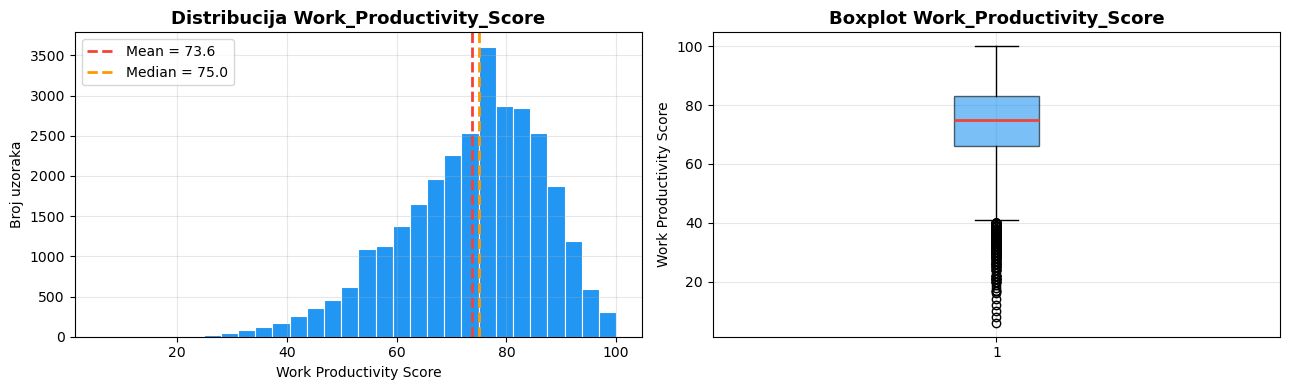

Min:    6
Max:    100
Mean:   73.64
Median: 75.00
Std:    13.12


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(dataset['Work_Productivity_Score'], bins=30,
             color='#2196F3', edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribucija Work_Productivity_Score', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Work Productivity Score')
axes[0].set_ylabel('Broj uzoraka')
axes[0].axvline(dataset['Work_Productivity_Score'].mean(), color='#F44336',
                linewidth=2, linestyle='--', label=f'Mean = {dataset["Work_Productivity_Score"].mean():.1f}')
axes[0].axvline(dataset['Work_Productivity_Score'].median(), color='#FF9800',
                linewidth=2, linestyle='--', label=f'Median = {dataset["Work_Productivity_Score"].median():.1f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(dataset['Work_Productivity_Score'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#2196F3', alpha=0.6),
                medianprops=dict(color='#F44336', linewidth=2))
axes[1].set_title('Boxplot Work_Productivity_Score', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Work Productivity Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Min:    {dataset["Work_Productivity_Score"].min():.0f}')
print(f'Max:    {dataset["Work_Productivity_Score"].max():.0f}')
print(f'Mean:   {dataset["Work_Productivity_Score"].mean():.2f}')
print(f'Median: {dataset["Work_Productivity_Score"].median():.2f}')
print(f'Std:    {dataset["Work_Productivity_Score"].std():.2f}')

#### Korelaciona matrica feature-a

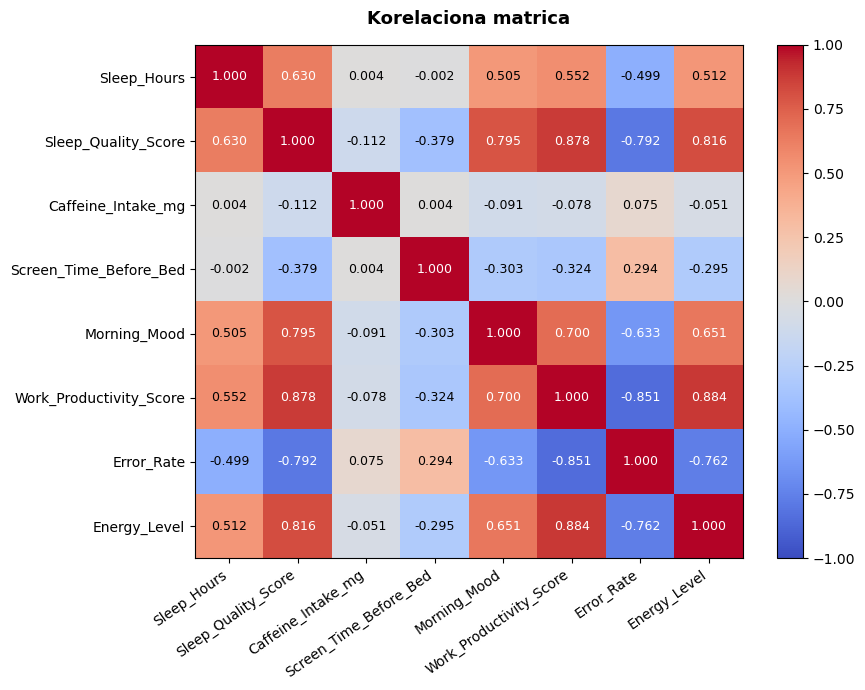

Korelacija sa Work_Productivity_Score (sortirano):
Energy_Level              0.884053
Sleep_Quality_Score       0.877801
Morning_Mood              0.700160
Sleep_Hours               0.552399
Caffeine_Intake_mg       -0.077774
Screen_Time_Before_Bed   -0.323615
Error_Rate               -0.851021


In [9]:
corr = dataset.corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')

labels = corr.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=10)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_title('Korelaciona matrica', fontsize=13, fontweight='bold', pad=15)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr.values[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9, color=color)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print('Korelacija sa Work_Productivity_Score (sortirano):')
print(corr['Work_Productivity_Score'].drop('Work_Productivity_Score').sort_values(ascending=False).to_string())

#### Scatter plot — feature-i vs <i>Work_Productivity_Score</i>

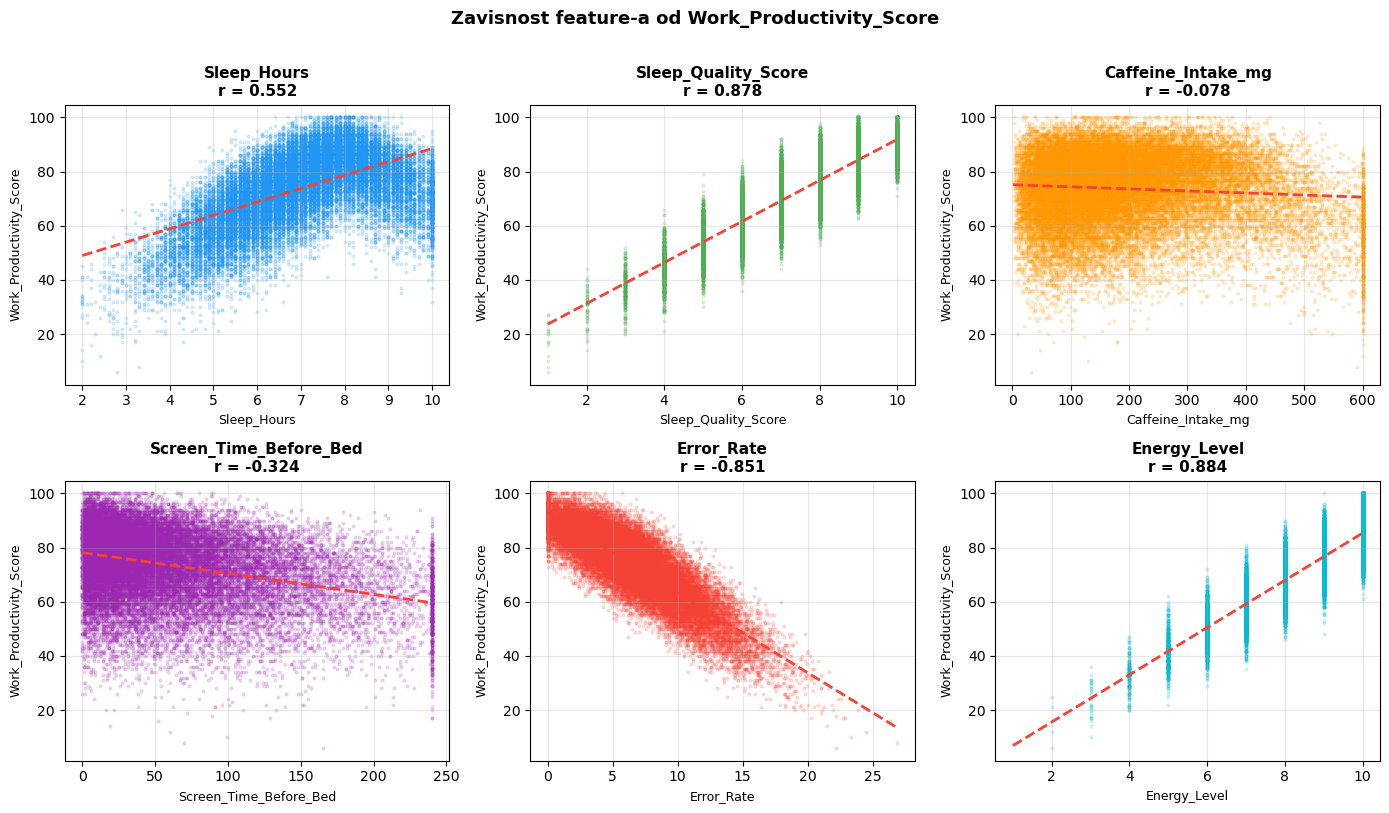

In [10]:
num_features = ['Sleep_Hours', 'Sleep_Quality_Score', 'Caffeine_Intake_mg',
                'Screen_Time_Before_Bed', 'Error_Rate', 'Energy_Level']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
colors_scatter = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336', '#00BCD4']

for i, col in enumerate(num_features):
    r = dataset[col].corr(dataset['Work_Productivity_Score'])
    axes[i].scatter(dataset[col], dataset['Work_Productivity_Score'],
                    alpha=0.15, s=4, color=colors_scatter[i])
    z = np.polyfit(dataset[col], dataset['Work_Productivity_Score'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(dataset[col].min(), dataset[col].max(), 100)
    axes[i].plot(x_line, p(x_line), color='#F44336', linewidth=2, linestyle='--')
    axes[i].set_title(f'{col}\nr = {r:.3f}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel('Work_Productivity_Score', fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Zavisnost feature-a od Work_Productivity_Score',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### <i>Morning_Mood</i> vs <i>Work_Productivity_Score</i>

/var/folders/r8/ld1vjw5x7sj5mk7hfs3q28sr0000gn/T/ipykernel_42935/3239374769.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(mood_groups, labels=mood_labels, patch_artist=True,


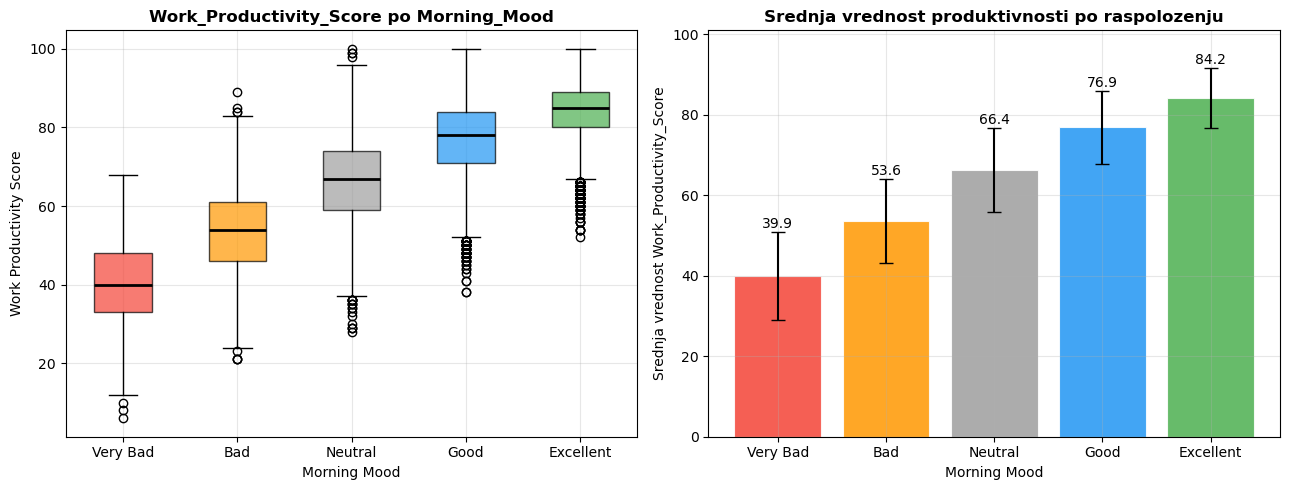

In [11]:
mood_labels = ['Very Bad', 'Bad', 'Neutral', 'Good', 'Excellent']
colors_mood = ['#F44336', '#FF9800', '#9E9E9E', '#2196F3', '#4CAF50']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

mood_groups = [dataset[dataset['Morning_Mood'] == i]['Work_Productivity_Score']
               for i in range(5)]
bp = axes[0].boxplot(mood_groups, labels=mood_labels, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors_mood):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Work_Productivity_Score po Morning_Mood', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Morning Mood')
axes[0].set_ylabel('Work Productivity Score')
axes[0].grid(True, alpha=0.3)

means = [g.mean() for g in mood_groups]
stds  = [g.std() for g in mood_groups]
axes[1].bar(mood_labels, means, color=colors_mood, edgecolor='white',
            linewidth=0.8, alpha=0.85, yerr=stds, capsize=5)
axes[1].set_title('Srednja vrednost produktivnosti po raspolozenju', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Morning Mood')
axes[1].set_ylabel('Srednja vrednost Work_Productivity_Score')
for i, (m, s) in enumerate(zip(means, stds)):
    axes[1].text(i, m + s + 1, f'{m:.1f}', ha='center', fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, max(means) * 1.2)

plt.tight_layout()
plt.show()

#### Heatmapa: <i>Sleep_Hours</i> × <i>Sleep_Quality_Score</i> → <i>Work_Productivity_Score</i>

/var/folders/r8/ld1vjw5x7sj5mk7hfs3q28sr0000gn/T/ipykernel_42935/2373501981.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = dataset.pivot_table(


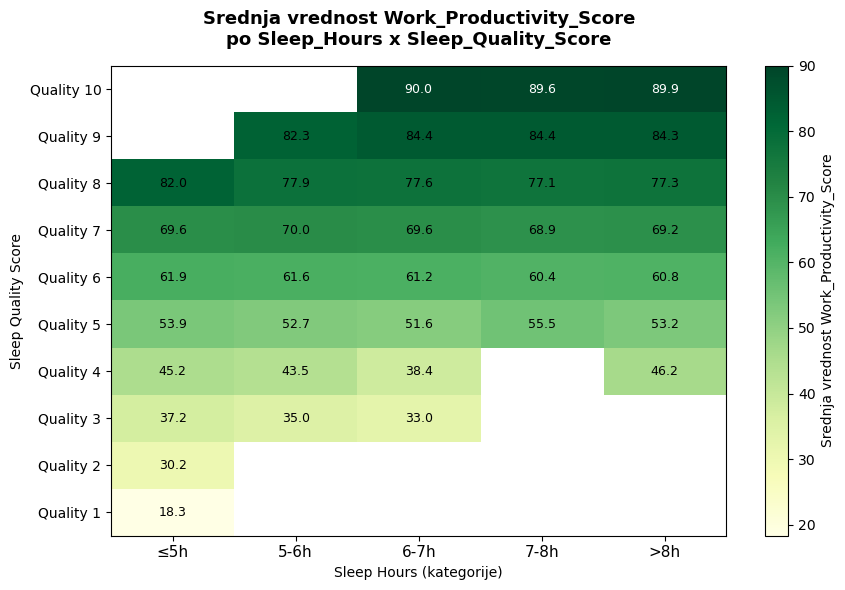

In [12]:
dataset['sleep_bin'] = pd.cut(dataset['Sleep_Hours'],
                               bins=[1.9, 5, 6, 7, 8, 10.1],
                               labels=['≤5h', '5-6h', '6-7h', '7-8h', '>8h'])

pivot = dataset.pivot_table(
    values='Work_Productivity_Score',
    index='Sleep_Quality_Score',
    columns='sleep_bin',
    aggfunc='mean'
)
pivot = pivot.sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(pivot.values, cmap='YlGn', aspect='auto',
               vmin=pivot.values[~np.isnan(pivot.values)].min(),
               vmax=pivot.values[~np.isnan(pivot.values)].max())

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=11)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'Quality {v}' for v in pivot.index], fontsize=10)
ax.set_title('Srednja vrednost Work_Productivity_Score\npo Sleep_Hours x Sleep_Quality_Score',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Sleep Hours (kategorije)')
ax.set_ylabel('Sleep Quality Score')

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=9,
                    color='black' if val < 85 else 'white')

plt.colorbar(im, ax=ax, label='Srednja vrednost Work_Productivity_Score')
plt.tight_layout()
plt.show()

dataset = dataset.drop(columns=['sleep_bin'])

#### Distribucija svih feature-a

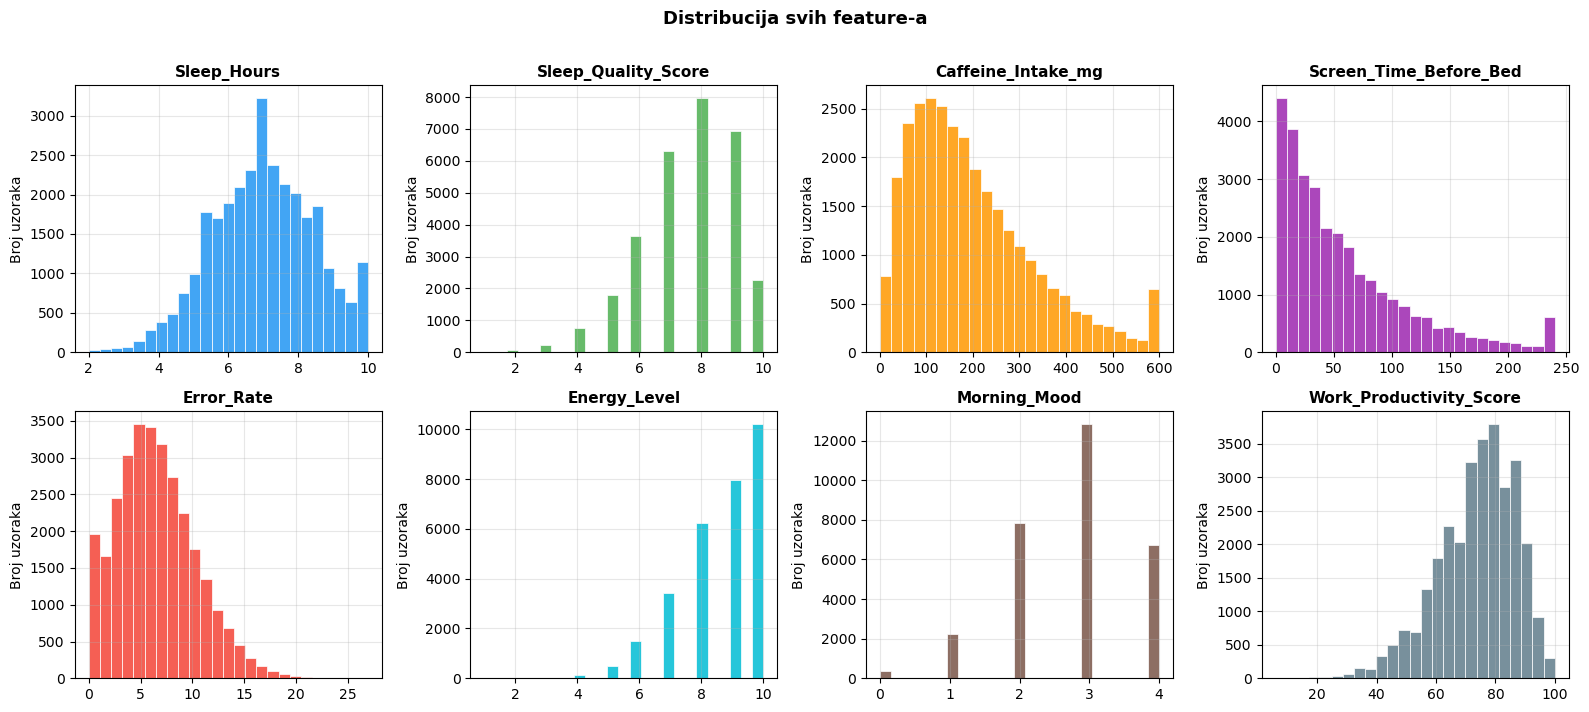

In [13]:
all_features = ['Sleep_Hours', 'Sleep_Quality_Score', 'Caffeine_Intake_mg',
                'Screen_Time_Before_Bed', 'Error_Rate', 'Energy_Level',
                'Morning_Mood', 'Work_Productivity_Score']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
palette = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4','#795548','#607D8B']

for i, col in enumerate(all_features):
    axes[i].hist(dataset[col], bins=25, color=palette[i],
                 edgecolor='white', linewidth=0.6, alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Broj uzoraka')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Distribucija svih feature-a', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = dataset.drop(columns=['Work_Productivity_Score']).astype(float).values
y = dataset['Work_Productivity_Score'].values.astype(float)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"Train:      {X_train_s.shape[0]:,} uzoraka")
print(f"Validation: {X_val_s.shape[0]:,} uzoraka")
print(f"Test:       {X_test_s.shape[0]:,} uzoraka")
print(f"Broj feature-a: {X_train_s.shape[1]}")
print(f"\nTarget statistike (train):")
print(f"  Mean:  {y_train.mean():.2f}")
print(f"  Std:   {y_train.std():.2f}")
print(f"  Min:   {y_train.min():.0f}")
print(f"  Max:   {y_train.max():.0f}")

Train:      21,000 uzoraka
Validation: 4,500 uzoraka
Test:       4,500 uzoraka
Broj feature-a: 7

Target statistike (train):
  Mean:  73.67
  Std:   13.12
  Min:   8
  Max:   100


In [15]:
y_mean_pred = np.full_like(y_test, fill_value=y_train.mean())

mae_baseline  = mean_absolute_error(y_test, y_mean_pred)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_mean_pred))
r2_baseline   = r2_score(y_test, y_mean_pred)

print("=" * 50)
print("BASELINE — Mean Predictor")
print("=" * 50)
print(f"  MAE:  {mae_baseline:.4f}")
print(f"  RMSE: {rmse_baseline:.4f}")
print(f"  R²:   {r2_baseline:.4f}")
print()
print(f"Uvek predviđa: {y_train.mean():.2f}")
print("(Ovo je minimalni prag koji svaki model mora da premaši)")

BASELINE — Mean Predictor
  MAE:  10.3249
  RMSE: 12.9558
  R²:   -0.0001

Uvek predviđa: 73.67
(Ovo je minimalni prag koji svaki model mora da premaši)


In [16]:
def build_baseline_model(input_dim):
    inputs = keras.Input(shape=(input_dim,), name="input")

    x = layers.Dense(64, activation='relu', name="dense_1")(inputs)
    x = layers.Dense(32, activation='relu', name="dense_2")(x)

    outputs = layers.Dense(1, name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs,
                        name="Baseline_SleepNet")
    return model

baseline_model = build_baseline_model(input_dim=X_train_s.shape[1])
baseline_model.summary()

Model: "Baseline_SleepNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625 (10.25 KB)

 Trainable params: 2,625 (10.25 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mean_squared_error',
    metrics=['mae']
)

In [18]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

In [19]:
history = baseline_model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=100,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

print(f"\nTreniranje završeno.")
print(f"Broj otrenirani epoha: {len(history.history['loss'])}")
print(f"Finalna train MAE:      {history.history['mae'][-1]:.4f}")
print(f"Finalna validation MAE: {history.history['val_mae'][-1]:.4f}")

Epoch 1/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5025.4819 - mae: 69.5474 - val_loss: 3907.0906 - val_mae: 60.9367 - learning_rate: 0.0010
Epoch 2/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 631us/step - loss: 2160.2502 - mae: 42.4769 - val_loss: 891.2618 - val_mae: 25.3586 - learning_rate: 0.0010
Epoch 3/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 695us/step - loss: 687.2540 - mae: 21.9717 - val_loss: 487.5527 - val_mae: 18.4136 - learning_rate: 0.0010
Epoch 4/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 638us/step - loss: 362.2378 - mae: 15.5263 - val_loss: 252.1125 - val_mae: 12.7989 - learning_rate: 0.0010
Epoch 5/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 623us/step - loss: 203.5459 - mae: 11.3406 - val_loss: 162.0989 - val_mae: 10.0194 - learning_rate: 0.0010
Epoch 6/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 617us/step - loss: 142.7012 - mae: 9.3906 - val_loss: 122.6441 - val_mae: 8.6322 - learning_rate: 0.0010
Epoch 7/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 629us/step - loss: 111.4282 - mae: 8.2621 - val_loss: 97.8559 - v

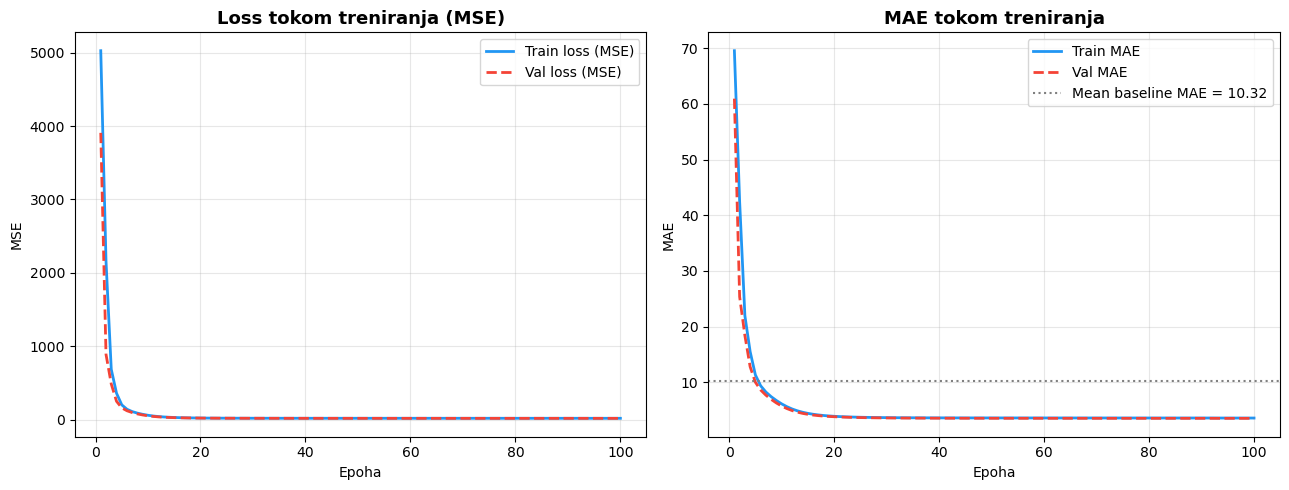

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = range(1, len(history.history['loss']) + 1)

axes[0].plot(epochs_range, history.history['loss'],
             label='Train loss (MSE)', color='#2196F3', linewidth=2)
axes[0].plot(epochs_range, history.history['val_loss'],
             label='Val loss (MSE)', color='#F44336', linewidth=2, linestyle='--')
axes[0].set_title('Loss tokom treniranja (MSE)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history.history['mae'],
             label='Train MAE', color='#2196F3', linewidth=2)
axes[1].plot(epochs_range, history.history['val_mae'],
             label='Val MAE', color='#F44336', linewidth=2, linestyle='--')
axes[1].axhline(y=mae_baseline, color='gray', linestyle=':',
                linewidth=1.5, label=f'Mean baseline MAE = {mae_baseline:.2f}')
axes[1].set_title('MAE tokom treniranja', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
test_loss, test_mae = baseline_model.evaluate(X_test_s, y_test, verbose=0)
y_pred = baseline_model.predict(X_test_s, verbose=0).flatten()

test_rmse = np.sqrt(test_loss)
test_r2   = r2_score(y_test, y_pred)

print("=" * 55)
print("EVALUACIJA — Baseline SleepNet (Test set)")
print("=" * 55)
print(f"  MAE:  {test_mae:.4f}   (baseline: {mae_baseline:.4f})")
print(f"  RMSE: {test_rmse:.4f}   (baseline: {rmse_baseline:.4f})")
print(f"  R²:   {test_r2:.4f}   (baseline: {r2_baseline:.4f})")
print("-" * 55)
print(f"  Poboljšanje MAE:  {mae_baseline - test_mae:+.4f}")
print(f"  Poboljšanje R²:   {test_r2 - r2_baseline:+.4f}")
print("=" * 55)

EVALUACIJA — Baseline SleepNet (Test set)
  MAE:  3.5552   (baseline: 10.3249)
  RMSE: 4.4475   (baseline: 12.9558)
  R²:   0.8821   (baseline: -0.0001)
-------------------------------------------------------
  Poboljšanje MAE:  +6.7697
  Poboljšanje R²:   +0.8822


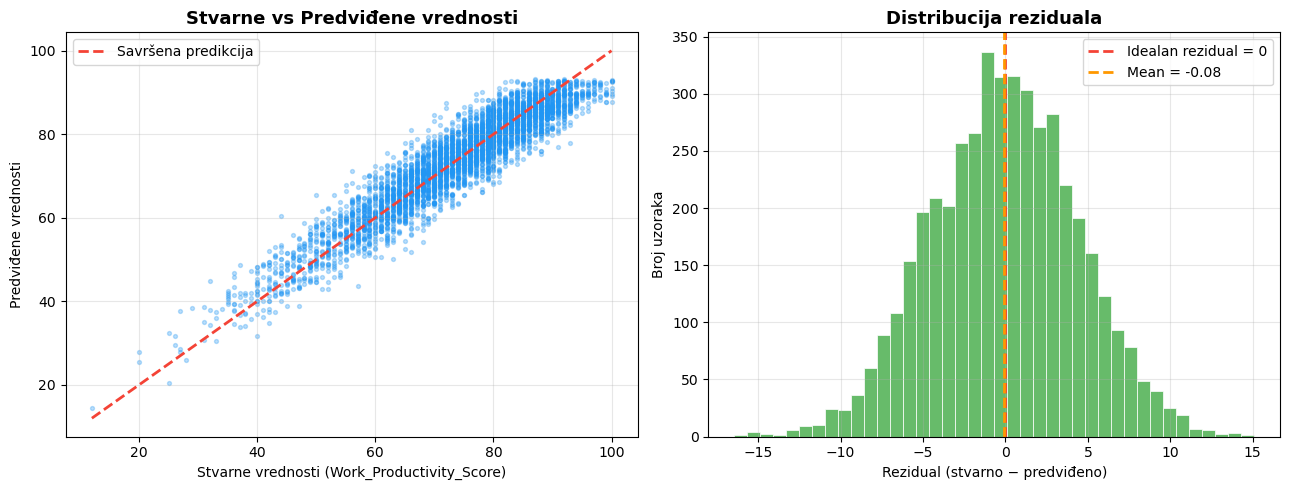

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=8, color='#2196F3')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#F44336', linewidth=2, linestyle='--', label='Savršena predikcija')
axes[0].set_title('Stvarne vs Predviđene vrednosti', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Stvarne vrednosti (Work_Productivity_Score)')
axes[0].set_ylabel('Predviđene vrednosti')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals = y_test - y_pred
axes[1].hist(residuals, bins=40, color='#4CAF50',
             edgecolor='white', linewidth=0.6, alpha=0.85)
axes[1].axvline(x=0, color='#F44336', linewidth=2,
                linestyle='--', label='Idealan rezidual = 0')
axes[1].axvline(x=residuals.mean(), color='#FF9800', linewidth=2,
                linestyle='--', label=f'Mean = {residuals.mean():.2f}')
axes[1].set_title('Distribucija reziduala', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rezidual (stvarno − predviđeno)')
axes[1].set_ylabel('Broj uzoraka')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
def build_final_model(input_dim, dropout_rate=0.2, l2_lambda=1e-4):
    inputs = keras.Input(shape=(input_dim,), name="input")

    x = layers.Dense(
        256, activation='relu',
        kernel_regularizer=regularizers.l2(l2_lambda),
        name="dense_1"
    )(inputs)
    x = layers.BatchNormalization(name="bn_1")(x)
    x = layers.Dropout(dropout_rate, name="dropout_1")(x)

    x = layers.Dense(
        128, activation='relu',
        kernel_regularizer=regularizers.l2(l2_lambda),
        name="dense_2"
    )(x)
    x = layers.BatchNormalization(name="bn_2")(x)
    x = layers.Dropout(dropout_rate, name="dropout_2")(x)

    x = layers.Dense(
        64, activation='relu',
        kernel_regularizer=regularizers.l2(l2_lambda),
        name="dense_3"
    )(x)
    x = layers.BatchNormalization(name="bn_3")(x)
    x = layers.Dropout(dropout_rate / 2, name="dropout_3")(x)

    x = layers.Dense(
        32, activation='relu',
        kernel_regularizer=regularizers.l2(l2_lambda),
        name="dense_4"
    )(x)
    x = layers.BatchNormalization(name="bn_4")(x)

    outputs = layers.Dense(1, name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="Final_SleepNet")
    return model

final_model = build_final_model(input_dim=X_train_s.shape[1])
final_model.summary()

Model: "Final_SleepNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_4 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,233 (184.50 KB)

 Trainable params: 46,273 (180.75 KB)

 Non-trainable params: 960 (3.75 KB)

In [24]:
final_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mean_squared_error',
    metrics=['mae']
)

In [25]:
callbacks_final = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    )
]

In [26]:
history_final = final_model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=150,
    batch_size=256,
    callbacks=callbacks_final,
    verbose=1
)

print(f"\nTreniranje završeno.")
print(f"Broj otrenirani epoha: {len(history_final.history['loss'])}")
print(f"Finalna train MAE:      {history_final.history['mae'][-1]:.4f}")
print(f"Finalna validation MAE: {history_final.history['val_mae'][-1]:.4f}")

Epoch 1/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5441.1704 - mae: 73.3018 - val_loss: 5335.6689 - val_mae: 72.5287 - learning_rate: 0.0010
Epoch 2/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5224.6211 - mae: 72.0848 - val_loss: 5046.2222 - val_mae: 70.7336 - learning_rate: 0.0010
Epoch 3/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4929.6826 - mae: 70.0279 - val_loss: 4773.4937 - val_mae: 68.8900 - learning_rate: 0.0010
Epoch 4/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4516.3164 - mae: 67.0024 - val_loss: 4416.7266 - val_mae: 66.2112 - learning_rate: 0.0010
Epoch 5/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3979.7437 - mae: 62.8862 - val_loss: 3773.1582 - val_mae: 61.2141 - learning_rate: 0.0010
Epoch 6/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3373.3088 - mae: 57.8606 - val_loss: 3074.8481 - val_mae: 55.2619 - learning_rate: 0.0010
Epoch 7/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2744.1270 - mae: 52.1376 - val_loss: 2414.1223 

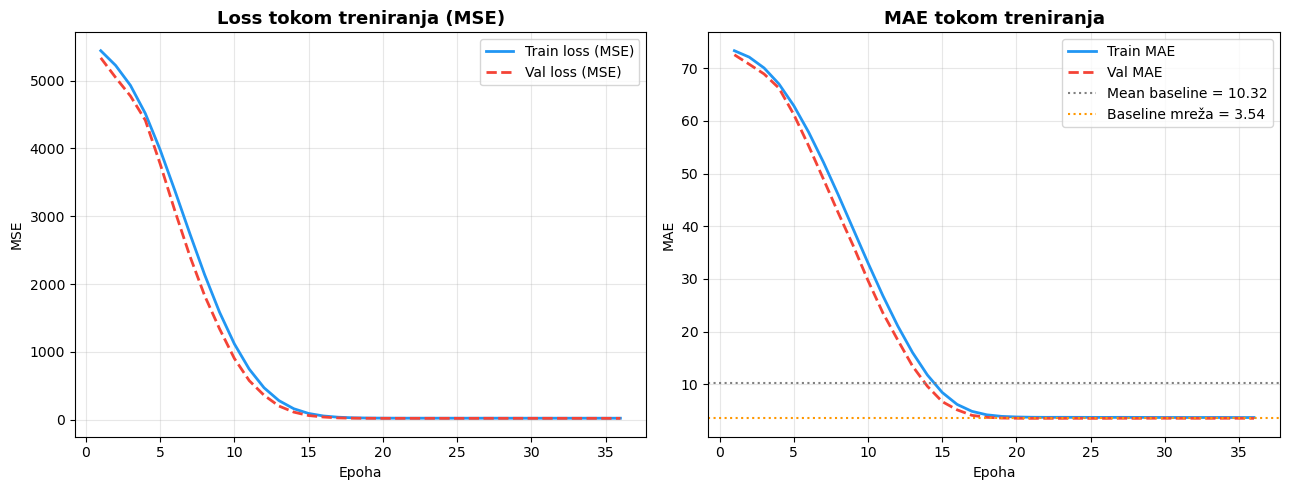

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = range(1, len(history_final.history['loss']) + 1)

axes[0].plot(epochs_range, history_final.history['loss'],
             label='Train loss (MSE)', color='#2196F3', linewidth=2)
axes[0].plot(epochs_range, history_final.history['val_loss'],
             label='Val loss (MSE)', color='#F44336',
             linewidth=2, linestyle='--')
axes[0].set_title('Loss tokom treniranja (MSE)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_final.history['mae'],
             label='Train MAE', color='#2196F3', linewidth=2)
axes[1].plot(epochs_range, history_final.history['val_mae'],
             label='Val MAE', color='#F44336',
             linewidth=2, linestyle='--')
axes[1].axhline(y=mae_baseline, color='gray', linestyle=':',
                linewidth=1.5, label=f'Mean baseline = {mae_baseline:.2f}')
axes[1].axhline(y=history.history['val_mae'][-1], color='#FF9800',
                linestyle=':', linewidth=1.5,
                label=f'Baseline mreža = {history.history["val_mae"][-1]:.2f}')
axes[1].set_title('MAE tokom treniranja', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
test_loss_f, test_mae_f = final_model.evaluate(X_test_s, y_test, verbose=0)
y_pred_f = final_model.predict(X_test_s, verbose=0).flatten()

test_rmse_f = np.sqrt(test_loss_f)
test_r2_f   = r2_score(y_test, y_pred_f)

print("=" * 60)
print("POREĐENJE MODELA — Test set")
print("=" * 60)
print(f"{'Model':<25} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 60)
print(f"{'Mean Predictor':<25} {mae_baseline:>8.4f} {rmse_baseline:>8.4f} {r2_baseline:>8.4f}")
print(f"{'Baseline SleepNet':<25} {test_mae:>8.4f} {test_rmse:>8.4f} {test_r2:>8.4f}")
print(f"{'Final SleepNet':<25} {test_mae_f:>8.4f} {test_rmse_f:>8.4f} {test_r2_f:>8.4f}")
print("=" * 60)
print(f"\nPoboljšanje finalnog vs baseline mreže:")
print(f"  MAE:  {test_mae - test_mae_f:+.4f}")
print(f"  RMSE: {test_rmse - test_rmse_f:+.4f}")
print(f"  R²:   {test_r2_f - test_r2:+.4f}")

POREĐENJE MODELA — Test set
Model                          MAE     RMSE       R²
------------------------------------------------------------
Mean Predictor             10.3249  12.9558  -0.0001
Baseline SleepNet           3.5552   4.4475   0.8821
Final SleepNet              3.5725   4.4845   0.8804

Poboljšanje finalnog vs baseline mreže:
  MAE:  -0.0173
  RMSE: -0.0371
  R²:   -0.0018


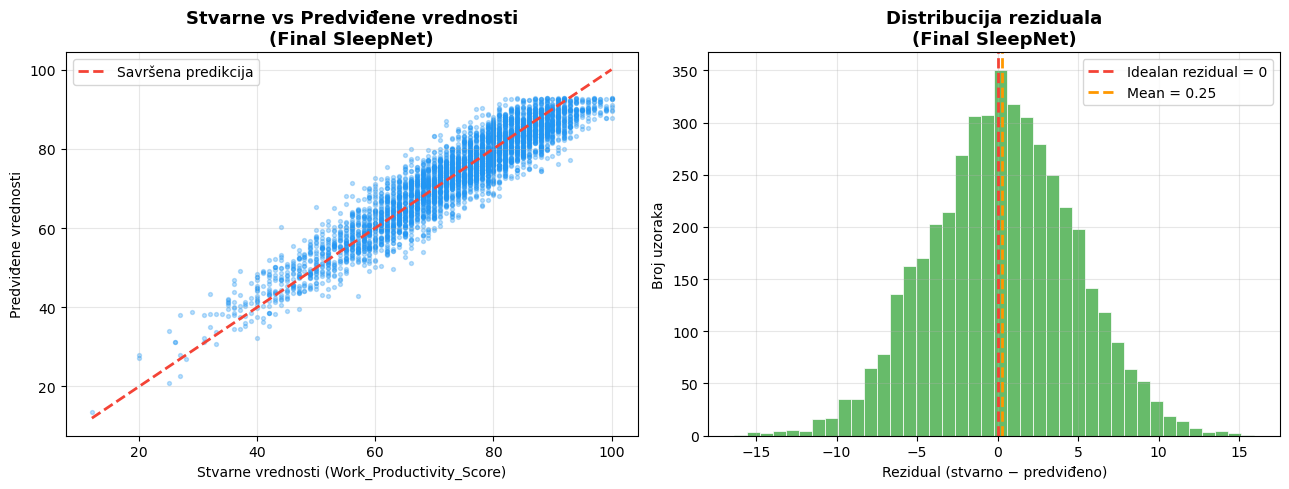

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_f, alpha=0.3, s=8, color='#2196F3')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#F44336', linewidth=2,
             linestyle='--', label='Savršena predikcija')
axes[0].set_title('Stvarne vs Predviđene vrednosti\n(Final SleepNet)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Stvarne vrednosti (Work_Productivity_Score)')
axes[0].set_ylabel('Predviđene vrednosti')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals_f = y_test - y_pred_f
axes[1].hist(residuals_f, bins=40, color='#4CAF50',
             edgecolor='white', linewidth=0.6, alpha=0.85)
axes[1].axvline(x=0, color='#F44336', linewidth=2,
                linestyle='--', label='Idealan rezidual = 0')
axes[1].axvline(x=residuals_f.mean(), color='#FF9800', linewidth=2,
                linestyle='--', label=f'Mean = {residuals_f.mean():.2f}')
axes[1].set_title('Distribucija reziduala\n(Final SleepNet)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rezidual (stvarno − predviđeno)')
axes[1].set_ylabel('Broj uzoraka')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

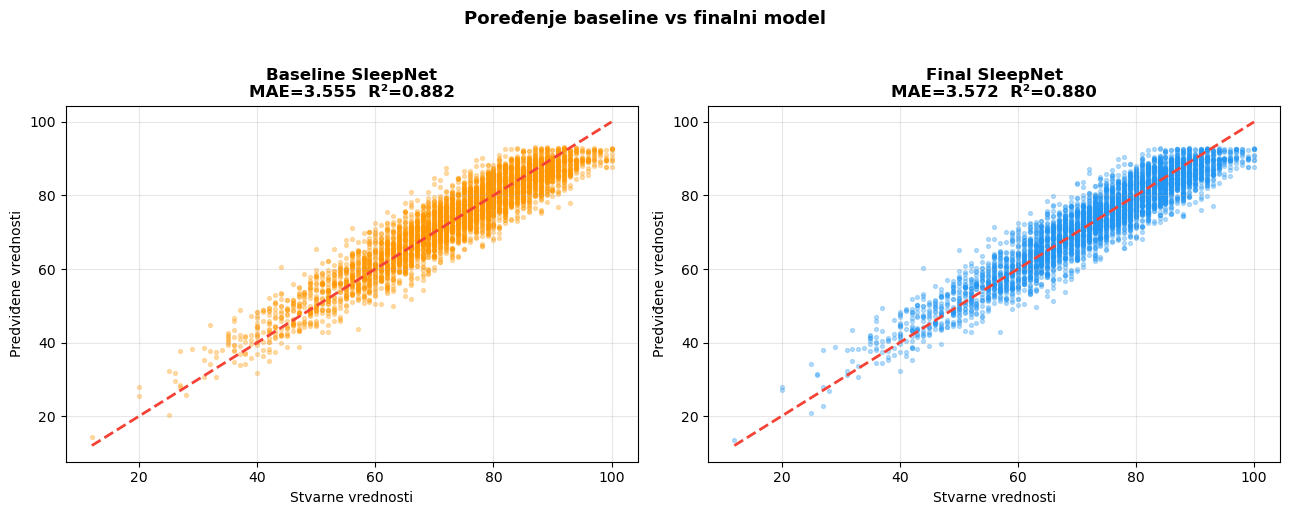

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=8, color='#FF9800')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#F44336', linewidth=2, linestyle='--')
axes[0].set_title(f'Baseline SleepNet\nMAE={test_mae:.3f}  R²={test_r2:.3f}',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Stvarne vrednosti')
axes[0].set_ylabel('Predviđene vrednosti')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, y_pred_f, alpha=0.3, s=8, color='#2196F3')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#F44336', linewidth=2, linestyle='--')
axes[1].set_title(f'Final SleepNet\nMAE={test_mae_f:.3f}  R²={test_r2_f:.3f}',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Stvarne vrednosti')
axes[1].set_ylabel('Predviđene vrednosti')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Poređenje baseline vs finalni model',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Zapažanje: Rezultati finalnog modela su gori od baseline rezultata.

### Feature engineering
Kombinovano sleep score, stres indikatori, kvardatni termini za nelinearne efekte

In [31]:
dataset['sleep_combined']    = dataset['Sleep_Hours'] * dataset['Sleep_Quality_Score']
dataset['sleep_efficiency']  = dataset['Sleep_Quality_Score'] / (dataset['Sleep_Hours'] + 1e-6)

dataset['stress_index']      = dataset['Caffeine_Intake_mg'] * dataset['Screen_Time_Before_Bed']
dataset['caffeine_per_hour'] = dataset['Caffeine_Intake_mg'] / (dataset['Sleep_Hours'] + 1e-6)

dataset['error_sq']          = dataset['Error_Rate'] ** 2
dataset['energy_mood']       = dataset['Energy_Level'] * dataset['Morning_Mood']


In [32]:
eng_features = ['sleep_combined', 'sleep_efficiency', 'stress_index',
                'caffeine_per_hour', 'error_sq', 'energy_mood']
try:
    _ = dataset
    need_load = not all(c in dataset.columns for c in eng_features)
except NameError:
    need_load = True
if need_load:
    dataset = pd.read_csv('Sleep_Patterns_vs_Daily_Performance.csv')
    mood_order = ['Very Bad', 'Bad', 'Neutral', 'Good', 'Excellent']
    mood_map = {m: i for i, m in enumerate(mood_order)}
    dataset['Morning_Mood'] = dataset['Morning_Mood'].map(mood_map)
    if 'sleep_bin' in dataset.columns:
        dataset = dataset.drop(columns=['sleep_bin'])
    dataset['sleep_combined']    = dataset['Sleep_Hours'] * dataset['Sleep_Quality_Score']
    dataset['sleep_efficiency']  = dataset['Sleep_Quality_Score'] / (dataset['Sleep_Hours'] + 1e-6)
    dataset['stress_index']      = dataset['Caffeine_Intake_mg'] * dataset['Screen_Time_Before_Bed']
    dataset['caffeine_per_hour'] = dataset['Caffeine_Intake_mg'] / (dataset['Sleep_Hours'] + 1e-6)
    dataset['error_sq']          = dataset['Error_Rate'] ** 2
    dataset['energy_mood']       = dataset['Energy_Level'] * dataset['Morning_Mood']

print(f"Originalni feature-i: 7")
print(f"Novi (engineered) feature-i: {dataset.shape[1] - 1 - 7}")
print(f"Ukupno feature-a: {dataset.shape[1] - 1}")
print()

print("Korelacija novih feature-a sa Work_Productivity_Score:")
print("-" * 50)
for col in eng_features:
    r = dataset[col].corr(dataset['Work_Productivity_Score'])
    print(f"  {col:<22}  r = {r:+.4f}")

print()
print("Korelacija originalnih feature-a sa Work_Productivity_Score:")
print("-" * 50)
orig_features = ['Sleep_Hours', 'Sleep_Quality_Score', 'Caffeine_Intake_mg',
                 'Screen_Time_Before_Bed', 'Morning_Mood', 'Error_Rate', 'Energy_Level']
for col in orig_features:
    r = dataset[col].corr(dataset['Work_Productivity_Score'])
    print(f"  {col:<28}  r = {r:+.4f}")


Originalni feature-i: 7
Novi (engineered) feature-i: 6
Ukupno feature-a: 13

Korelacija novih feature-a sa Work_Productivity_Score:
--------------------------------------------------
  sleep_combined          r = +0.7807
  sleep_efficiency        r = +0.3637
  stress_index            r = -0.2652
  caffeine_per_hour       r = -0.2886
  error_sq                r = -0.8285
  energy_mood             r = +0.8028

Korelacija originalnih feature-a sa Work_Productivity_Score:
--------------------------------------------------
  Sleep_Hours                   r = +0.5524
  Sleep_Quality_Score           r = +0.8778
  Caffeine_Intake_mg            r = -0.0778
  Screen_Time_Before_Bed        r = -0.3236
  Morning_Mood                  r = +0.7002
  Error_Rate                    r = -0.8510
  Energy_Level                  r = +0.8841


### Priprema podataka sa feature-engineered skupom

Novi split i scaler koji uključuju svih 13 feature-a (7 originalnih + 6 novih).  
Isti podeli kao prethodni modeli (`random_state=42`) — test skup je identičan.

In [33]:

X_fe = dataset.drop(columns=['Work_Productivity_Score']).astype(float).values
y_fe = dataset['Work_Productivity_Score'].values.astype(float)

X_fe_train, X_fe_temp, y_fe_train, y_fe_temp = train_test_split(
    X_fe, y_fe, test_size=0.30, random_state=42
)
X_fe_val, X_fe_test, y_fe_val, y_fe_test = train_test_split(
    X_fe_temp, y_fe_temp, test_size=0.50, random_state=42
)

scaler_fe = StandardScaler()
X_fe_train_s = scaler_fe.fit_transform(X_fe_train)
X_fe_val_s   = scaler_fe.transform(X_fe_val)
X_fe_test_s  = scaler_fe.transform(X_fe_test)

print(f"Train:      {X_fe_train_s.shape[0]:,} uzoraka")
print(f"Validation: {X_fe_val_s.shape[0]:,} uzoraka")
print(f"Test:       {X_fe_test_s.shape[0]:,} uzoraka")
print(f"Broj feature-a: {X_fe_train_s.shape[1]}")


Train:      21,000 uzoraka
Validation: 4,500 uzoraka
Test:       4,500 uzoraka
Broj feature-a: 13


### Model: Final_FeatureEng_SleepNet

Arhitektura je namerno zadržana jednostavna (bez dropout-a i bez BatchNorm), identična stilu baseline modela koji se pokazao najboljim.  
Jedina razlika je **veći input** (13 feature-a) i **malo širi** prvi sloj — da iskoristi bogaTiji ulaz.

In [34]:

def build_feature_eng_model(input_dim):
    inputs = keras.Input(shape=(input_dim,), name="input")

    x = layers.Dense(128, activation='relu', name="dense_1")(inputs)
    x = layers.Dense(64,  activation='relu', name="dense_2")(x)
    x = layers.Dense(32,  activation='relu', name="dense_3")(x)

    outputs = layers.Dense(1, name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs,
                        name="Final_FeatureEng_SleepNet")
    return model

fe_model = build_feature_eng_model(input_dim=X_fe_train_s.shape[1])
fe_model.summary()


Model: "Final_FeatureEng_SleepNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 13)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,161 (47.50 KB)

 Trainable params: 12,161 (47.50 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:

fe_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mean_squared_error',
    metrics=['mae']
)

callbacks_fe = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]


In [36]:

history_fe = fe_model.fit(
    X_fe_train_s, y_fe_train,
    validation_data=(X_fe_val_s, y_fe_val),
    epochs=100,
    batch_size=256,
    callbacks=callbacks_fe,
    verbose=1
)

print(f"\nTreniranje završeno.")
print(f"Broj otrenirani epoha: {len(history_fe.history['loss'])}")
print(f"Finalna train MAE:      {history_fe.history['mae'][-1]:.4f}")
print(f"Finalna validation MAE: {history_fe.history['val_mae'][-1]:.4f}")


Epoch 1/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2882.5952 - mae: 47.1453 - val_loss: 460.7466 - val_mae: 17.5225 - learning_rate: 0.0010
Epoch 2/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 857us/step - loss: 296.9502 - mae: 13.5026 - val_loss: 208.0971 - val_mae: 11.2330 - learning_rate: 0.0010
Epoch 3/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step - loss: 165.4683 - mae: 9.9602 - val_loss: 122.8556 - val_mae: 8.5825 - learning_rate: 0.0010
Epoch 4/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 843us/step - loss: 98.1266 - mae: 7.6957 - val_loss: 70.4838 - val_mae: 6.5504 - learning_rate: 0.0010
Epoch 5/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 853us/step - loss: 57.2279 - mae: 5.9419 - val_loss: 42.9818 - val_mae: 5.1634 - learning_rate: 0.0010
Epoch 6/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 852us/step - loss: 37.4161 - mae: 4.8474 - val_loss: 30.6861 - val_mae: 4.3857 - learning_rate: 0.0010
Epoch 7/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step - loss: 28.5505 - mae: 4.2460 - val_loss: 25.0965 - val_mae: 3.9774 

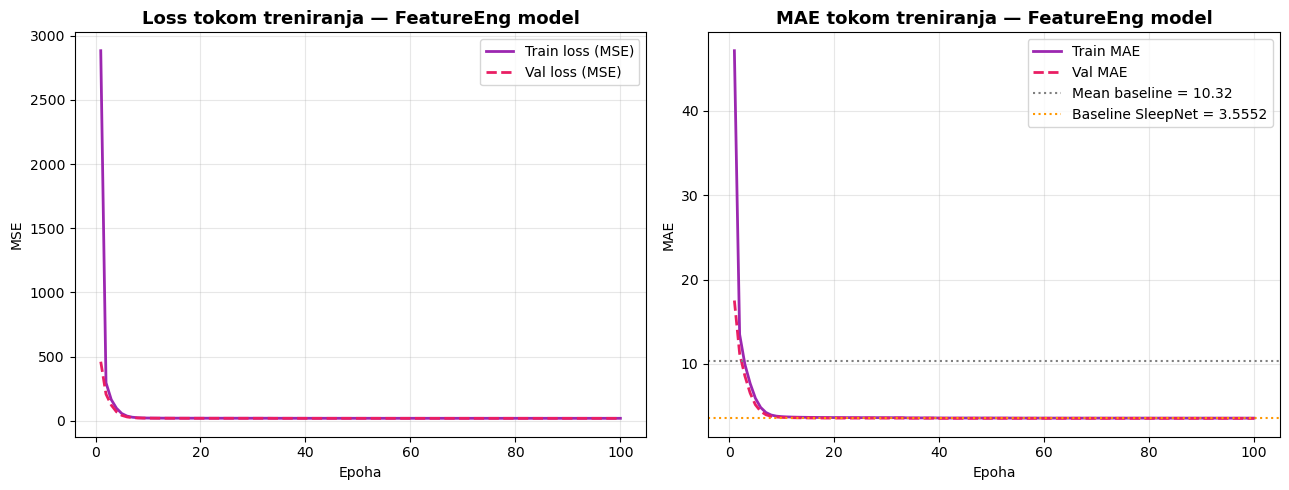

In [37]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = range(1, len(history_fe.history['loss']) + 1)

axes[0].plot(epochs_range, history_fe.history['loss'],
             label='Train loss (MSE)', color='#9C27B0', linewidth=2)
axes[0].plot(epochs_range, history_fe.history['val_loss'],
             label='Val loss (MSE)', color='#E91E63', linewidth=2, linestyle='--')
axes[0].set_title('Loss tokom treniranja — FeatureEng model', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_fe.history['mae'],
             label='Train MAE', color='#9C27B0', linewidth=2)
axes[1].plot(epochs_range, history_fe.history['val_mae'],
             label='Val MAE', color='#E91E63', linewidth=2, linestyle='--')
axes[1].axhline(y=mae_baseline, color='gray', linestyle=':',
                linewidth=1.5, label=f'Mean baseline = {mae_baseline:.2f}')
axes[1].axhline(y=test_mae, color='#FF9800', linestyle=':',
                linewidth=1.5, label=f'Baseline SleepNet = {test_mae:.4f}')
axes[1].set_title('MAE tokom treniranja — FeatureEng model', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


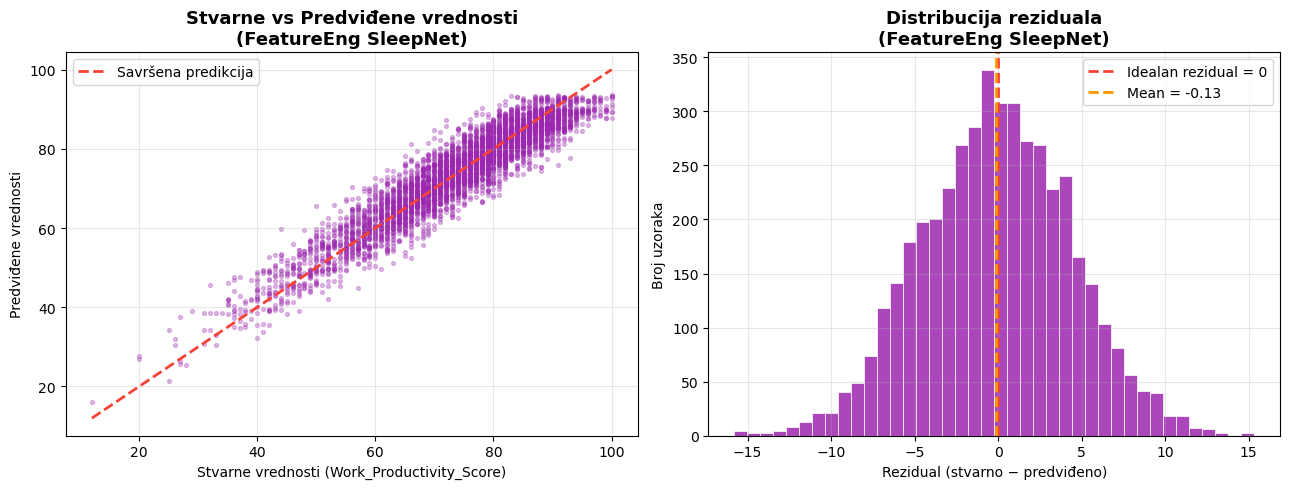

In [38]:

test_loss_fe, test_mae_fe = fe_model.evaluate(X_fe_test_s, y_fe_test, verbose=0)
y_pred_fe = fe_model.predict(X_fe_test_s, verbose=0).flatten()

test_rmse_fe = np.sqrt(test_loss_fe)
test_r2_fe   = r2_score(y_fe_test, y_pred_fe)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_fe_test, y_pred_fe, alpha=0.3, s=8, color='#9C27B0')
axes[0].plot([y_fe_test.min(), y_fe_test.max()],
             [y_fe_test.min(), y_fe_test.max()],
             color='#F44336', linewidth=2, linestyle='--', label='Savršena predikcija')
axes[0].set_title(f'Stvarne vs Predviđene vrednosti\n(FeatureEng SleepNet)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Stvarne vrednosti (Work_Productivity_Score)')
axes[0].set_ylabel('Predviđene vrednosti')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals_fe = y_fe_test - y_pred_fe
axes[1].hist(residuals_fe, bins=40, color='#9C27B0',
             edgecolor='white', linewidth=0.6, alpha=0.85)
axes[1].axvline(x=0, color='#F44336', linewidth=2,
                linestyle='--', label='Idealan rezidual = 0')
axes[1].axvline(x=residuals_fe.mean(), color='#FF9800', linewidth=2,
                linestyle='--', label=f'Mean = {residuals_fe.mean():.2f}')
axes[1].set_title('Distribucija reziduala\n(FeatureEng SleepNet)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rezidual (stvarno − predviđeno)')
axes[1].set_ylabel('Broj uzoraka')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [39]:

print("=" * 70)
print("POREĐENJE SVIH MODELA — Test set")
print("=" * 70)
print(f"{'Model':<30} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'Epohe':>7} {'Feature-i':>10}")
print("-" * 70)
print(f"{'Mean Predictor':<30} {mae_baseline:>8.4f} {rmse_baseline:>8.4f} {r2_baseline:>8.4f} {'—':>7} {'7':>10}")
print(f"{'Baseline SleepNet':<30} {test_mae:>8.4f} {test_rmse:>8.4f} {test_r2:>8.4f} {'80':>7} {'7':>10}")
print(f"{'Final SleepNet v1':<30} {test_mae_f:>8.4f} {test_rmse_f:>8.4f} {test_r2_f:>8.4f} {'44':>7} {'7':>10}")
print(f"{'FeatureEng SleepNet':<30} {test_mae_fe:>8.4f} {test_rmse_fe:>8.4f} {test_r2_fe:>8.4f} {len(history_fe.history['loss']):>7} {'13':>10}")
print("=" * 70)
print(f"\nPoboljšanje FeatureEng vs Baseline SleepNet:")
print(f"  MAE:  {test_mae - test_mae_fe:+.4f}  ({(test_mae - test_mae_fe)/test_mae*100:+.2f}%)")
print(f"  RMSE: {test_rmse - test_rmse_fe:+.4f}  ({(test_rmse - test_rmse_fe)/test_rmse*100:+.2f}%)")
print(f"  R²:   {test_r2_fe - test_r2:+.4f}")


POREĐENJE SVIH MODELA — Test set
Model                               MAE     RMSE       R²   Epohe  Feature-i
----------------------------------------------------------------------
Mean Predictor                  10.3249  12.9558  -0.0001       —          7
Baseline SleepNet                3.5552   4.4475   0.8821      80          7
Final SleepNet v1                3.5725   4.4845   0.8804      44          7
FeatureEng SleepNet              3.5785   4.4775   0.8806     100         13

Poboljšanje FeatureEng vs Baseline SleepNet:
  MAE:  -0.0232  (-0.65%)
  RMSE: -0.0300  (-0.68%)
  R²:   -0.0016


---
## Residualna mreža — ResNet_SleepNet

Umesto da povećavamo dubinu ili širinu, uvodimo **skip connections** (residualne veze) koje preskaču slojeve.

**Zašto residualne veze?**
- Gradient može da "prođe" direktno unazad kroz skip vezu, bez degradacije
- Model uči **rezidual** (korekciju) umesto pune transformacije
- Čak i ako novi slojevi ne pomažu, mreža može da "ignoriše" blok postavivši težine na ≈0 i koristiti skip
- Arhitektura: `Input → Projekcija(64) → [ResBlok1] → [ResBlok2] → Dense(32) → Output`
- Svaki ResBlok: `Dense→BN→ReLU→Dense→BN→Add(skip)→ReLU`
- Isti 7 originalnih feature-a kao baseline — testiramo čistu razliku u arhitekturi

In [40]:

def build_residual_model(input_dim):
    inputs = keras.Input(shape=(input_dim,), name="input")

    # Ulazna projekcija na 64 dimenzije
    x = layers.Dense(64, name="projection")(inputs)

    # --- Residualni blok 1 ---
    skip1 = x
    x = layers.Dense(64, name="res1_dense1")(x)
    x = layers.BatchNormalization(name="res1_bn1")(x)
    x = layers.Activation('relu', name="res1_relu1")(x)
    x = layers.Dense(64, name="res1_dense2")(x)
    x = layers.BatchNormalization(name="res1_bn2")(x)
    x = layers.Add(name="res1_add")([x, skip1])
    x = layers.Activation('relu', name="res1_out")(x)

    # --- Residualni blok 2 ---
    skip2 = x
    x = layers.Dense(64, name="res2_dense1")(x)
    x = layers.BatchNormalization(name="res2_bn1")(x)
    x = layers.Activation('relu', name="res2_relu1")(x)
    x = layers.Dense(64, name="res2_dense2")(x)
    x = layers.BatchNormalization(name="res2_bn2")(x)
    x = layers.Add(name="res2_add")([x, skip2])
    x = layers.Activation('relu', name="res2_out")(x)

    # Izlazna glava
    x = layers.Dense(32, activation='relu', name="head")(x)
    outputs = layers.Dense(1, name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="ResNet_SleepNet")
    return model

resnet_model = build_residual_model(input_dim=X_train_s.shape[1])
resnet_model.summary()


Model: "ResNet_SleepNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 7)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ projection (Dense)  │ (None, 64)        │        512 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_dense1 (Dense) │ (None, 64)        │      4,160 │ projection[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_bn1            │ (None, 64)        │        256 │ res1_dense1[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_relu1          │ (None, 64)        │          0 │ res1_bn1[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_dense2 (Dense) │ (None, 64)        │      4,160 │ res1_relu1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_bn2            │ (None, 64)        │        256 │ res1_dense2[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_add (Add)      │ (None, 64)        │          0 │ res1_bn2[0][0],   │
│                     │                   │            │ projection[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_out            │ (None, 64)        │          0 │ res1_add[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_dense1 (Dense) │ (None, 64)        │      4,160 │ res1_out[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_bn1            │ (None, 64)        │        256 │ res2_dense1[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_relu1          │ (None, 64)        │          0 │ res2_bn1[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_dense2 (Dense) │ (None, 64)        │      4,160 │ res2_relu1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_bn2            │ (None, 64)        │        256 │ res2_dense2[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_add (Add)      │ (None, 64)        │          0 │ res2_bn2[0][0],   │
│                     │                   │            │ res1_out[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_out            │ (None, 64)        │          0 │ res2_add[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head (Dense)        │ (None, 32)        │      2,080 │ res2_out[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ head[0][0]        │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 19,777 (77.25 KB)

 Non-trainable params: 512 (2.00 KB)

In [41]:

resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mean_squared_error',
    metrics=['mae']
)

callbacks_resnet = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]


In [42]:

history_resnet = resnet_model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=100,
    batch_size=256,
    callbacks=callbacks_resnet,
    verbose=1
)

print(f"\nTreniranje završeno.")
print(f"Broj otrenirani epoha: {len(history_resnet.history['loss'])}")
print(f"Finalna train MAE:      {history_resnet.history['mae'][-1]:.4f}")
print(f"Finalna validation MAE: {history_resnet.history['val_mae'][-1]:.4f}")


Epoch 1/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3597.6514 - mae: 58.0708 - val_loss: 2230.4519 - val_mae: 45.9890 - learning_rate: 0.0010
Epoch 2/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 186.7198 - mae: 9.8358 - val_loss: 457.4540 - val_mae: 20.3006 - learning_rate: 0.0010
Epoch 3/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 25.5885 - mae: 4.0237 - val_loss: 158.7704 - val_mae: 11.4796 - learning_rate: 0.0010
Epoch 4/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 24.5174 - mae: 3.9415 - val_loss: 71.4260 - val_mae: 7.2275 - learning_rate: 0.0010
Epoch 5/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 24.0073 - mae: 3.9006 - val_loss: 44.6992 - val_mae: 5.4983 - learning_rate: 0.0010
Epoch 6/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 23.6002 - mae: 3.8678 - val_loss: 34.9310 - val_mae: 4.7846 - learning_rate: 0.0010
Epoch 7/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 23.2980 - mae: 3.8437 - val_loss: 30.3699 - val_mae: 4.4317 - learning_r

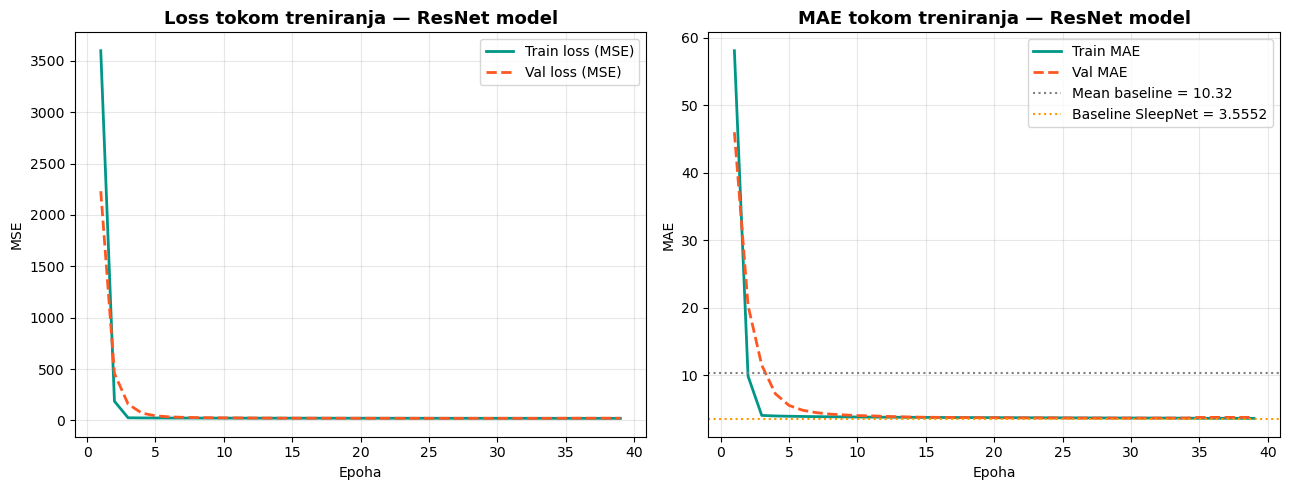

In [43]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = range(1, len(history_resnet.history['loss']) + 1)

axes[0].plot(epochs_range, history_resnet.history['loss'],
             label='Train loss (MSE)', color='#009688', linewidth=2)
axes[0].plot(epochs_range, history_resnet.history['val_loss'],
             label='Val loss (MSE)', color='#FF5722', linewidth=2, linestyle='--')
axes[0].set_title('Loss tokom treniranja — ResNet model', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_resnet.history['mae'],
             label='Train MAE', color='#009688', linewidth=2)
axes[1].plot(epochs_range, history_resnet.history['val_mae'],
             label='Val MAE', color='#FF5722', linewidth=2, linestyle='--')
axes[1].axhline(y=mae_baseline, color='gray', linestyle=':',
                linewidth=1.5, label=f'Mean baseline = {mae_baseline:.2f}')
axes[1].axhline(y=test_mae, color='#FF9800', linestyle=':',
                linewidth=1.5, label=f'Baseline SleepNet = {test_mae:.4f}')
axes[1].set_title('MAE tokom treniranja — ResNet model', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


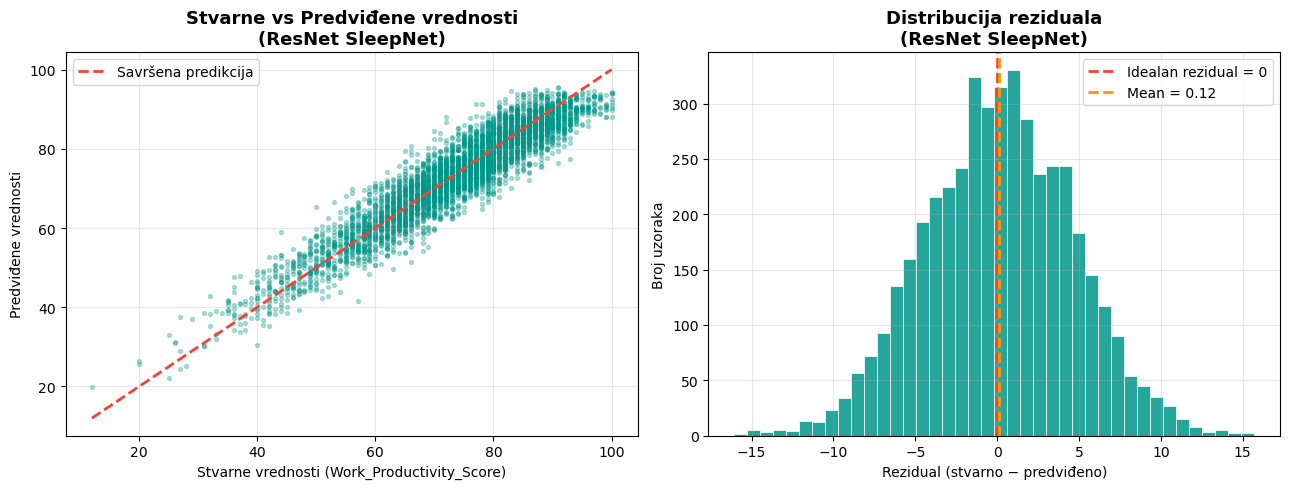

In [44]:

test_loss_res, test_mae_res = resnet_model.evaluate(X_test_s, y_test, verbose=0)
y_pred_res = resnet_model.predict(X_test_s, verbose=0).flatten()

test_rmse_res = np.sqrt(test_loss_res)
test_r2_res   = r2_score(y_test, y_pred_res)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_res, alpha=0.3, s=8, color='#009688')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#F44336', linewidth=2, linestyle='--', label='Savršena predikcija')
axes[0].set_title('Stvarne vs Predviđene vrednosti\n(ResNet SleepNet)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Stvarne vrednosti (Work_Productivity_Score)')
axes[0].set_ylabel('Predviđene vrednosti')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals_res = y_test - y_pred_res
axes[1].hist(residuals_res, bins=40, color='#009688',
             edgecolor='white', linewidth=0.6, alpha=0.85)
axes[1].axvline(x=0, color='#F44336', linewidth=2,
                linestyle='--', label='Idealan rezidual = 0')
axes[1].axvline(x=residuals_res.mean(), color='#FF9800', linewidth=2,
                linestyle='--', label=f'Mean = {residuals_res.mean():.2f}')
axes[1].set_title('Distribucija reziduala\n(ResNet SleepNet)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rezidual (stvarno − predviđeno)')
axes[1].set_ylabel('Broj uzoraka')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [45]:

print("=" * 70)
print("POREĐENJE SVIH MODELA — Test set")
print("=" * 70)
print(f"{'Model':<26} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'Epohe':>7}")
print("-" * 70)
print(f"{'Mean Predictor':<26} {mae_baseline:>8.4f} {rmse_baseline:>8.4f} {r2_baseline:>8.4f} {'—':>7}")
print(f"{'Baseline SleepNet':<26} {test_mae:>8.4f} {test_rmse:>8.4f} {test_r2:>8.4f} {len(history.history['loss']):>7}")
print(f"{'Final SleepNet v1':<26} {test_mae_f:>8.4f} {test_rmse_f:>8.4f} {test_r2_f:>8.4f} {len(history_final.history['loss']):>7}")
print(f"{'ResNet SleepNet':<26} {test_mae_res:>8.4f} {test_rmse_res:>8.4f} {test_r2_res:>8.4f} {len(history_resnet.history['loss']):>7}")
print("=" * 70)
print(f"\nPoboljšanje ResNet vs Baseline SleepNet:")
print(f"  MAE:  {test_mae - test_mae_res:+.4f}  ({(test_mae - test_mae_res) / test_mae * 100:+.2f}%)")
print(f"  RMSE: {test_rmse - test_rmse_res:+.4f}  ({(test_rmse - test_rmse_res) / test_rmse * 100:+.2f}%)")
print(f"  R²:   {test_r2_res - test_r2:+.4f}")


POREĐENJE SVIH MODELA — Test set
Model                           MAE     RMSE       R²   Epohe
----------------------------------------------------------------------
Mean Predictor              10.3249  12.9558  -0.0001       —
Baseline SleepNet            3.5552   4.4475   0.8821     100
Final SleepNet v1            3.5725   4.4845   0.8804      36
ResNet SleepNet              3.6330   4.5472   0.8768      39

Poboljšanje ResNet vs Baseline SleepNet:
  MAE:  -0.0777  (-2.19%)
  RMSE: -0.0997  (-2.24%)
  R²:   -0.0053


---
## Huber loss — Huber_SleepNet

Do sada svi modeli koriste **MSE (Mean Squared Error)** kao loss funkciju.  
Problem MSE-a: kvadratno kažnjava greške, pa su **outlieri** (npr. ekstremne vrednosti `Caffeine_Intake_mg`, `Screen_Time_Before_Bed`) disproporcionalno uticajni na gradijent.

**Huber loss** kombinuje MSE i MAE:
- Za male greške (|e| ≤ δ): ponaša se kao MSE → osetljiv na fine razlike
- Za velike greške (|e| > δ): ponaša se kao MAE → robustno na outliere, gradijent ne eksplodira

```
L(e) = 0.5 * e²              ako |e| ≤ δ
L(e) = δ * (|e| - 0.5 * δ)  ako |e| > δ
```

Koristimo δ=1.0 (standardna vrednost). Arhitektura je identična Baseline SleepNet (64→32, bez regularizacije) — testiramo **samo efekat loss funkcije**.

In [46]:

def build_huber_model(input_dim):
    inputs = keras.Input(shape=(input_dim,), name="input")

    x = layers.Dense(64, activation='relu', name="dense_1")(inputs)
    x = layers.Dense(32, activation='relu', name="dense_2")(x)

    outputs = layers.Dense(1, name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="Huber_SleepNet")
    return model

huber_model = build_huber_model(input_dim=X_train_s.shape[1])
huber_model.summary()


Model: "Huber_SleepNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625 (10.25 KB)

 Trainable params: 2,625 (10.25 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:

huber_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.Huber(delta=1.0),
    metrics=['mae']
)

callbacks_huber = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]


In [48]:

history_huber = huber_model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=100,
    batch_size=256,
    callbacks=callbacks_huber,
    verbose=1
)

print(f"\nTreniranje završeno.")
print(f"Broj otrenirani epoha: {len(history_huber.history['loss'])}")
print(f"Finalna train MAE:      {history_huber.history['mae'][-1]:.4f}")
print(f"Finalna validation MAE: {history_huber.history['val_mae'][-1]:.4f}")


Epoch 1/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 68.1483 - mae: 68.6482 - val_loss: 58.1240 - val_mae: 58.6236 - learning_rate: 0.0010
Epoch 2/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 657us/step - loss: 40.1704 - mae: 40.6689 - val_loss: 21.0232 - val_mae: 21.5189 - learning_rate: 0.0010
Epoch 3/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 671us/step - loss: 16.5468 - mae: 17.0409 - val_loss: 12.1094 - val_mae: 12.6016 - learning_rate: 0.0010
Epoch 4/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 659us/step - loss: 9.8983 - mae: 10.3872 - val_loss: 8.1094 - val_mae: 8.5979 - learning_rate: 0.0010
Epoch 5/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 652us/step - loss: 7.2317 - mae: 7.7169 - val_loss: 6.2426 - val_mae: 6.7241 - learning_rate: 0.0010
Epoch 6/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 644us/step - loss: 5.6744 - mae: 6.1560 - val_loss: 4.9662 - val_mae: 5.4467 - learning_rate: 0.0010
Epoch 7/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 647us/step - loss: 4.6222 - mae: 5.1005 - val_loss: 4.1353 - val_mae: 4.6120 - learning_r

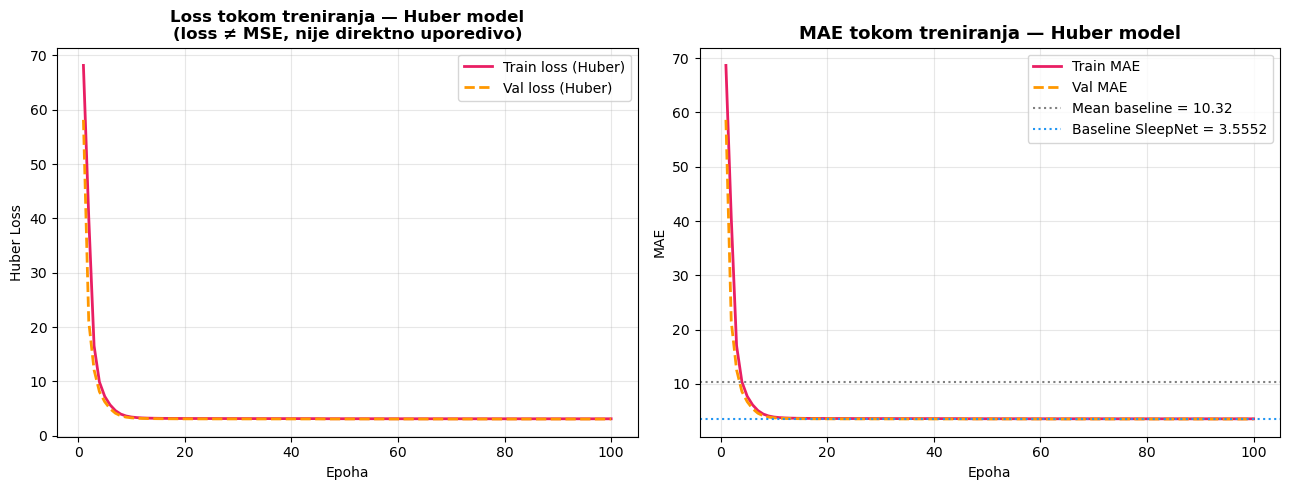

In [49]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = range(1, len(history_huber.history['loss']) + 1)

axes[0].plot(epochs_range, history_huber.history['loss'],
             label='Train loss (Huber)', color='#E91E63', linewidth=2)
axes[0].plot(epochs_range, history_huber.history['val_loss'],
             label='Val loss (Huber)', color='#FF9800', linewidth=2, linestyle='--')
axes[0].set_title('Loss tokom treniranja — Huber model\n(loss ≠ MSE, nije direktno uporedivo)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('Huber Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_huber.history['mae'],
             label='Train MAE', color='#E91E63', linewidth=2)
axes[1].plot(epochs_range, history_huber.history['val_mae'],
             label='Val MAE', color='#FF9800', linewidth=2, linestyle='--')
axes[1].axhline(y=mae_baseline, color='gray', linestyle=':',
                linewidth=1.5, label=f'Mean baseline = {mae_baseline:.2f}')
axes[1].axhline(y=test_mae, color='#2196F3', linestyle=':',
                linewidth=1.5, label=f'Baseline SleepNet = {test_mae:.4f}')
axes[1].set_title('MAE tokom treniranja — Huber model', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


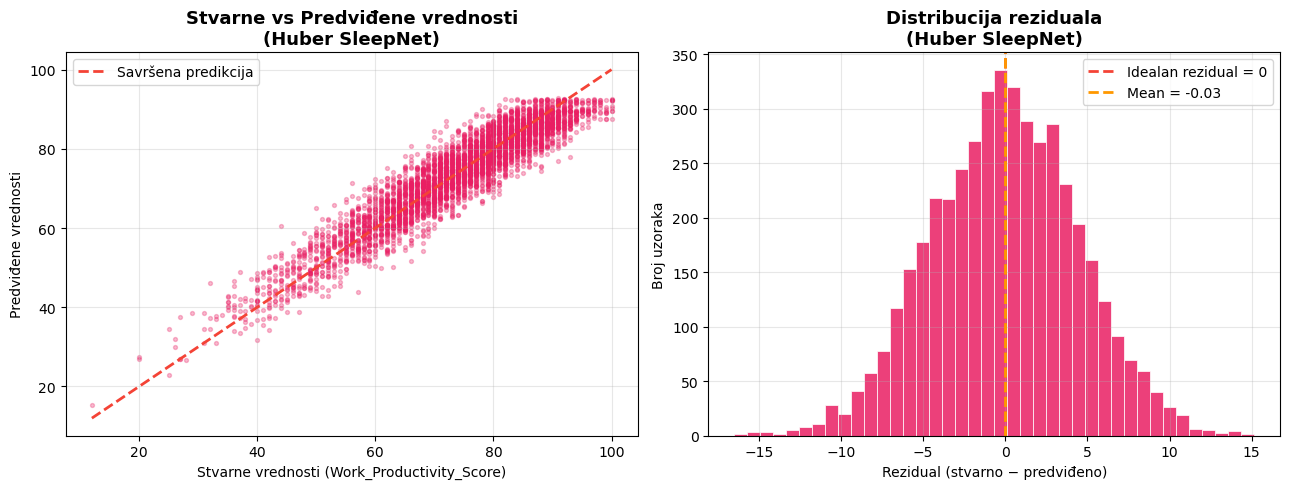

In [50]:

# Evaluacija — MSE/RMSE se računaju ručno jer je loss=Huber, ne MSE
y_pred_huber = huber_model.predict(X_test_s, verbose=0).flatten()

test_mae_huber  = mean_absolute_error(y_test, y_pred_huber)
test_rmse_huber = np.sqrt(mean_squared_error(y_test, y_pred_huber))
test_r2_huber   = r2_score(y_test, y_pred_huber)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_huber, alpha=0.3, s=8, color='#E91E63')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#F44336', linewidth=2, linestyle='--', label='Savršena predikcija')
axes[0].set_title('Stvarne vs Predviđene vrednosti\n(Huber SleepNet)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Stvarne vrednosti (Work_Productivity_Score)')
axes[0].set_ylabel('Predviđene vrednosti')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals_huber = y_test - y_pred_huber
axes[1].hist(residuals_huber, bins=40, color='#E91E63',
             edgecolor='white', linewidth=0.6, alpha=0.85)
axes[1].axvline(x=0, color='#F44336', linewidth=2,
                linestyle='--', label='Idealan rezidual = 0')
axes[1].axvline(x=residuals_huber.mean(), color='#FF9800', linewidth=2,
                linestyle='--', label=f'Mean = {residuals_huber.mean():.2f}')
axes[1].set_title('Distribucija reziduala\n(Huber SleepNet)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rezidual (stvarno − predviđeno)')
axes[1].set_ylabel('Broj uzoraka')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [51]:

print("=" * 70)
print("POREĐENJE SVIH MODELA — Test set")
print("=" * 70)
print(f"{'Model':<26} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'Epohe':>7} {'Loss':>8}")
print("-" * 70)
print(f"{'Mean Predictor':<26} {mae_baseline:>8.4f} {rmse_baseline:>8.4f} {r2_baseline:>8.4f} {'—':>7} {'—':>8}")
print(f"{'Baseline SleepNet':<26} {test_mae:>8.4f} {test_rmse:>8.4f} {test_r2:>8.4f} {len(history.history['loss']):>7} {'MSE':>8}")
print(f"{'Final SleepNet v1':<26} {test_mae_f:>8.4f} {test_rmse_f:>8.4f} {test_r2_f:>8.4f} {len(history_final.history['loss']):>7} {'MSE':>8}")
print(f"{'ResNet SleepNet':<26} {test_mae_res:>8.4f} {test_rmse_res:>8.4f} {test_r2_res:>8.4f} {len(history_resnet.history['loss']):>7} {'MSE':>8}")
print(f"{'Huber SleepNet':<26} {test_mae_huber:>8.4f} {test_rmse_huber:>8.4f} {test_r2_huber:>8.4f} {len(history_huber.history['loss']):>7} {'Huber':>8}")
print("=" * 70)
print(f"\nPoboljšanje Huber vs Baseline SleepNet:")
print(f"  MAE:  {test_mae - test_mae_huber:+.4f}  ({(test_mae - test_mae_huber) / test_mae * 100:+.2f}%)")
print(f"  RMSE: {test_rmse - test_rmse_huber:+.4f}  ({(test_rmse - test_rmse_huber) / test_rmse * 100:+.2f}%)")
print(f"  R²:   {test_r2_huber - test_r2:+.4f}")


POREĐENJE SVIH MODELA — Test set
Model                           MAE     RMSE       R²   Epohe     Loss
----------------------------------------------------------------------
Mean Predictor              10.3249  12.9558  -0.0001       —        —
Baseline SleepNet            3.5552   4.4475   0.8821     100      MSE
Final SleepNet v1            3.5725   4.4845   0.8804      36      MSE
ResNet SleepNet              3.6330   4.5472   0.8768      39      MSE
Huber SleepNet               3.5601   4.4566   0.8817     100    Huber

Poboljšanje Huber vs Baseline SleepNet:
  MAE:  -0.0048  (-0.14%)
  RMSE: -0.0092  (-0.21%)
  R²:   -0.0005


---
## Manji batch size + AdamW — AdamW_SleepNet

Dva odvojena poboljšanja u jednom eksperimentu:

**AdamW (Adam + Weight Decay):**
- Standardni Adam ugrađuje L2 regularizaciju u gradijent (što je matematički neispravno)
- AdamW ispravlja ovo odvajanjem weight decay-a od adaptivnog koraka
- Rezultat: bolja generalizacija bez eksplicitnog dodavanja L2 regularizatora

**Manji batch size (64 umesto 256):**
- Veliki batch → glatki, ali "ravni" gradijenti → model se lakše zaglavi u plitkim minimumima
- Mali batch → šumovitiiji gradijenti, ali → bolje istraživanje prostora parametara → bolji minimum
- Tradeoff: sporije po epohi, ali tipično manje epoha do konvergencije

Arhitektura ostaje ista kao Baseline SleepNet (64→32) — testiramo samo optimizator i batch size.

In [52]:

def build_adamw_model(input_dim):
    inputs = keras.Input(shape=(input_dim,), name="input")

    x = layers.Dense(64, activation='relu', name="dense_1")(inputs)
    x = layers.Dense(32, activation='relu', name="dense_2")(x)

    outputs = layers.Dense(1, name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="AdamW_SleepNet")
    return model

adamw_model = build_adamw_model(input_dim=X_train_s.shape[1])
adamw_model.summary()


Model: "AdamW_SleepNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625 (10.25 KB)

 Trainable params: 2,625 (10.25 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:

adamw_model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=5e-4, weight_decay=1e-5),
    loss='mean_squared_error',
    metrics=['mae']
)

callbacks_adamw = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]


In [54]:

history_adamw = adamw_model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=100,
    batch_size=64,
    callbacks=callbacks_adamw,
    verbose=1
)

print(f"\nTreniranje završeno.")
print(f"Broj otrenirani epoha: {len(history_adamw.history['loss'])}")
print(f"Finalna train MAE:      {history_adamw.history['mae'][-1]:.4f}")
print(f"Finalna validation MAE: {history_adamw.history['val_mae'][-1]:.4f}")


Epoch 1/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 648us/step - loss: 3395.0740 - mae: 53.7934 - val_loss: 775.6375 - val_mae: 23.8450 - learning_rate: 5.0000e-04
Epoch 2/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 414us/step - loss: 436.9677 - mae: 17.0361 - val_loss: 206.5943 - val_mae: 11.5184 - learning_rate: 5.0000e-04
Epoch 3/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 419us/step - loss: 146.8221 - mae: 9.5311 - val_loss: 105.5943 - val_mae: 8.0362 - learning_rate: 5.0000e-04
Epoch 4/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 415us/step - loss: 89.6226 - mae: 7.4201 - val_loss: 71.5359 - val_mae: 6.6147 - learning_rate: 5.0000e-04
Epoch 5/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 426us/step - loss: 62.8366 - mae: 6.2238 - val_loss: 51.0260 - val_mae: 5.6136 - learning_rate: 5.0000e-04
Epoch 6/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 424us/step - loss: 46.2720 - mae: 5.3582 - val_loss: 38.4217 - val_mae: 4.8837 - learning_rate: 5.0000e-04
Epoch 7/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 422us/step - loss: 35.9600 - mae: 4.739

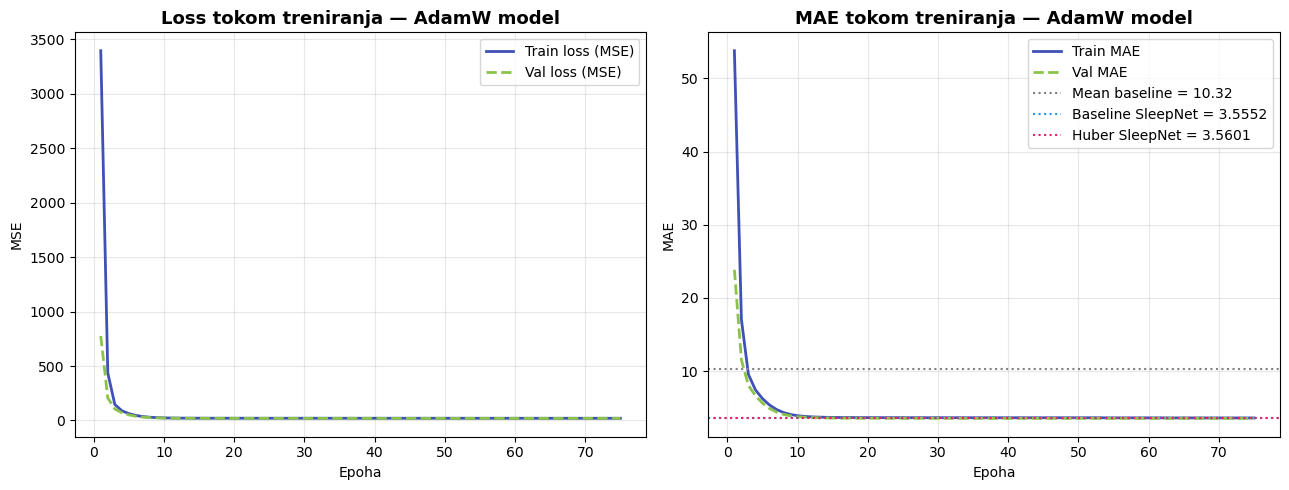

In [55]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = range(1, len(history_adamw.history['loss']) + 1)

axes[0].plot(epochs_range, history_adamw.history['loss'],
             label='Train loss (MSE)', color='#3F51B5', linewidth=2)
axes[0].plot(epochs_range, history_adamw.history['val_loss'],
             label='Val loss (MSE)', color='#8BC34A', linewidth=2, linestyle='--')
axes[0].set_title('Loss tokom treniranja — AdamW model', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_adamw.history['mae'],
             label='Train MAE', color='#3F51B5', linewidth=2)
axes[1].plot(epochs_range, history_adamw.history['val_mae'],
             label='Val MAE', color='#8BC34A', linewidth=2, linestyle='--')
axes[1].axhline(y=mae_baseline, color='gray', linestyle=':',
                linewidth=1.5, label=f'Mean baseline = {mae_baseline:.2f}')
axes[1].axhline(y=test_mae, color='#2196F3', linestyle=':',
                linewidth=1.5, label=f'Baseline SleepNet = {test_mae:.4f}')
axes[1].axhline(y=test_mae_huber, color='#E91E63', linestyle=':',
                linewidth=1.5, label=f'Huber SleepNet = {test_mae_huber:.4f}')
axes[1].set_title('MAE tokom treniranja — AdamW model', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


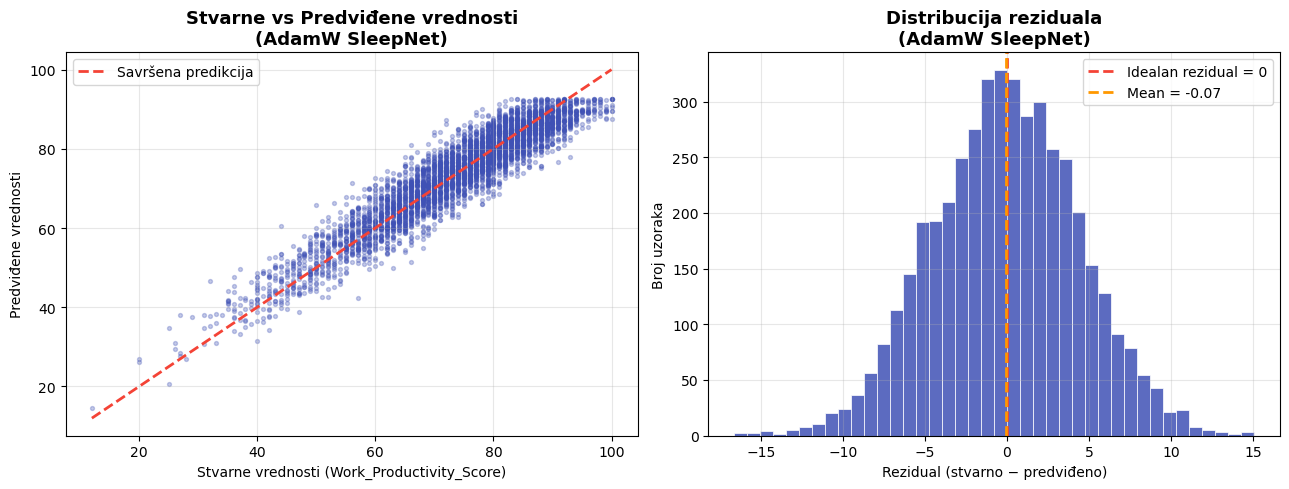

In [56]:

test_loss_adamw, test_mae_adamw = adamw_model.evaluate(X_test_s, y_test, verbose=0)
y_pred_adamw = adamw_model.predict(X_test_s, verbose=0).flatten()

test_rmse_adamw = np.sqrt(test_loss_adamw)
test_r2_adamw   = r2_score(y_test, y_pred_adamw)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_adamw, alpha=0.3, s=8, color='#3F51B5')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#F44336', linewidth=2, linestyle='--', label='Savršena predikcija')
axes[0].set_title('Stvarne vs Predviđene vrednosti\n(AdamW SleepNet)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Stvarne vrednosti (Work_Productivity_Score)')
axes[0].set_ylabel('Predviđene vrednosti')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals_adamw = y_test - y_pred_adamw
axes[1].hist(residuals_adamw, bins=40, color='#3F51B5',
             edgecolor='white', linewidth=0.6, alpha=0.85)
axes[1].axvline(x=0, color='#F44336', linewidth=2,
                linestyle='--', label='Idealan rezidual = 0')
axes[1].axvline(x=residuals_adamw.mean(), color='#FF9800', linewidth=2,
                linestyle='--', label=f'Mean = {residuals_adamw.mean():.2f}')
axes[1].set_title('Distribucija reziduala\n(AdamW SleepNet)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rezidual (stvarno − predviđeno)')
axes[1].set_ylabel('Broj uzoraka')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [57]:

print("=" * 75)
print("POREĐENJE SVIH MODELA — Test set")
print("=" * 75)
print(f"{'Model':<26} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'Epohe':>7} {'Loss':>8} {'Batch':>6}")
print("-" * 75)
print(f"{'Mean Predictor':<26} {mae_baseline:>8.4f} {rmse_baseline:>8.4f} {r2_baseline:>8.4f} {'—':>7} {'—':>8} {'—':>6}")
print(f"{'Baseline SleepNet':<26} {test_mae:>8.4f} {test_rmse:>8.4f} {test_r2:>8.4f} {len(history.history['loss']):>7} {'MSE':>8} {'256':>6}")
print(f"{'Final SleepNet v1':<26} {test_mae_f:>8.4f} {test_rmse_f:>8.4f} {test_r2_f:>8.4f} {len(history_final.history['loss']):>7} {'MSE':>8} {'256':>6}")
print(f"{'ResNet SleepNet':<26} {test_mae_res:>8.4f} {test_rmse_res:>8.4f} {test_r2_res:>8.4f} {len(history_resnet.history['loss']):>7} {'MSE':>8} {'256':>6}")
print(f"{'Huber SleepNet':<26} {test_mae_huber:>8.4f} {test_rmse_huber:>8.4f} {test_r2_huber:>8.4f} {len(history_huber.history['loss']):>7} {'Huber':>8} {'256':>6}")
print(f"{'AdamW SleepNet':<26} {test_mae_adamw:>8.4f} {test_rmse_adamw:>8.4f} {test_r2_adamw:>8.4f} {len(history_adamw.history['loss']):>7} {'MSE':>8} {'64':>6}")
print("=" * 75)

best_mae = min(test_mae, test_mae_f, test_mae_res, test_mae_huber, test_mae_adamw)
print(f"\nNajbolji MAE do sada:  {best_mae:.4f}")
print(f"Poboljšanje AdamW vs Baseline SleepNet:")
print(f"  MAE:  {test_mae - test_mae_adamw:+.4f}  ({(test_mae - test_mae_adamw) / test_mae * 100:+.2f}%)")
print(f"  RMSE: {test_rmse - test_rmse_adamw:+.4f}  ({(test_rmse - test_rmse_adamw) / test_rmse * 100:+.2f}%)")
print(f"  R²:   {test_r2_adamw - test_r2:+.4f}")


POREĐENJE SVIH MODELA — Test set
Model                           MAE     RMSE       R²   Epohe     Loss  Batch
---------------------------------------------------------------------------
Mean Predictor              10.3249  12.9558  -0.0001       —        —      —
Baseline SleepNet            3.5552   4.4475   0.8821     100      MSE    256
Final SleepNet v1            3.5725   4.4845   0.8804      36      MSE    256
ResNet SleepNet              3.6330   4.5472   0.8768      39      MSE    256
Huber SleepNet               3.5601   4.4566   0.8817     100    Huber    256
AdamW SleepNet               3.5570   4.4541   0.8818      75      MSE     64

Najbolji MAE do sada:  3.5552
Poboljšanje AdamW vs Baseline SleepNet:
  MAE:  -0.0017  (-0.05%)
  RMSE: -0.0067  (-0.15%)
  R²:   -0.0004


---
## Ensemble — Ensemble_SleepNet (5 modela)

Umesto jednog modela, treniramo **5 identičnih modela sa različitim random seedovima** i usrednjavamo njihove predikcije.

**Zašto ensemble funkcioniše?**
- Svaki model pravi različite greške (zbog različite inicijalizacije težina i redosleda batch-eva)
- Greške su delimično nekorelovane → usrednjavanje ih poništava
- Matematički: ako su greške modela $\varepsilon_i$ nekorelovane sa varijansom $\sigma^2$, tada varijansa ensemble-a = $\sigma^2 / N$

**Konfiguracija:**
- 5 modela, svaki sa seed-om: `[0, 7, 42, 123, 999]`
- Arhitektura: Huber SleepNet (64→32, Huber loss) — **best single model** do sada
- Finalna predikcija: `y_ensemble = mean(y_pred_1, ..., y_pred_5)`

In [58]:

SEEDS        = [0, 7, 42, 123, 999]
ensemble_preds_val  = []
ensemble_preds_test = []
ensemble_histories  = []

for i, seed in enumerate(SEEDS):
    print(f"\n{'='*55}")
    print(f"  Model {i+1}/5  —  seed = {seed}")
    print(f"{'='*55}")

    np.random.seed(seed)
    tf.random.set_seed(seed)

    m = keras.Sequential([
        keras.Input(shape=(X_train_s.shape[1],)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ], name=f"ensemble_model_{i+1}")

    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.Huber(delta=1.0),
        metrics=['mae']
    )

    cb = [
        EarlyStopping(monitor='val_loss', patience=10,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-6, verbose=0)
    ]

    hist = m.fit(
        X_train_s, y_train,
        validation_data=(X_val_s, y_val),
        epochs=100,
        batch_size=256,
        callbacks=cb,
        verbose=0
    )

    val_pred  = m.predict(X_val_s,  verbose=0).flatten()
    test_pred = m.predict(X_test_s, verbose=0).flatten()

    val_mae_i  = mean_absolute_error(y_val,  val_pred)
    test_mae_i = mean_absolute_error(y_test, test_pred)

    ensemble_preds_val.append(val_pred)
    ensemble_preds_test.append(test_pred)
    ensemble_histories.append(hist)

    print(f"  Epohe: {len(hist.history['loss']):>3}  |  "
          f"Val MAE: {val_mae_i:.4f}  |  Test MAE: {test_mae_i:.4f}")

print(f"\n{'='*55}")
print("  Treniranje svih 5 modela završeno.")
print(f"{'='*55}")



  Model 1/5  —  seed = 0
  Epohe:  47  |  Val MAE: 3.5378  |  Test MAE: 3.5639

  Model 2/5  —  seed = 7
  Epohe: 100  |  Val MAE: 3.5350  |  Test MAE: 3.5553

  Model 3/5  —  seed = 42
  Epohe: 100  |  Val MAE: 3.5408  |  Test MAE: 3.5648

  Model 4/5  —  seed = 123
  Epohe: 100  |  Val MAE: 3.5304  |  Test MAE: 3.5557

  Model 5/5  —  seed = 999
  Epohe:  63  |  Val MAE: 3.5239  |  Test MAE: 3.5563

  Treniranje svih 5 modela završeno.


In [59]:

# Ensemble predikcija — usrednjavanje svih 5 modela
y_pred_ensemble = np.mean(ensemble_preds_test, axis=0)

test_mae_ensemble  = mean_absolute_error(y_test, y_pred_ensemble)
test_rmse_ensemble = np.sqrt(mean_squared_error(y_test, y_pred_ensemble))
test_r2_ensemble   = r2_score(y_test, y_pred_ensemble)

# Prikaz doprinosa svakog modela
print(f"{'Model':<20} {'Val MAE':>10} {'Test MAE':>10}")
print("-" * 42)
for i, (seed, hist, test_pred) in enumerate(
        zip(SEEDS, ensemble_histories, ensemble_preds_test)):
    vm = mean_absolute_error(y_val,  ensemble_preds_val[i])
    tm = mean_absolute_error(y_test, test_pred)
    print(f"  Seed {seed:<6} (m{i+1})  {vm:>10.4f} {tm:>10.4f}")
print("-" * 42)
print(f"  {'ENSEMBLE':>14}  {'':>10} {test_mae_ensemble:>10.4f}")
print(f"\nPoboljšanje ensemble vs best single (Huber):")
print(f"  MAE:  {test_mae_huber - test_mae_ensemble:+.4f}  "
      f"({(test_mae_huber - test_mae_ensemble) / test_mae_huber * 100:+.2f}%)")
print(f"  RMSE: {test_rmse_huber - test_rmse_ensemble:+.4f}  "
      f"({(test_rmse_huber - test_rmse_ensemble) / test_rmse_huber * 100:+.2f}%)")
print(f"  R²:   {test_r2_ensemble - test_r2_huber:+.4f}")


Model                   Val MAE   Test MAE
------------------------------------------
  Seed 0      (m1)      3.5378     3.5639
  Seed 7      (m2)      3.5350     3.5553
  Seed 42     (m3)      3.5408     3.5648
  Seed 123    (m4)      3.5304     3.5557
  Seed 999    (m5)      3.5239     3.5563
------------------------------------------
        ENSEMBLE                 3.5506

Poboljšanje ensemble vs best single (Huber):
  MAE:  +0.0095  (+0.27%)
  RMSE: +0.0094  (+0.21%)
  R²:   +0.0005


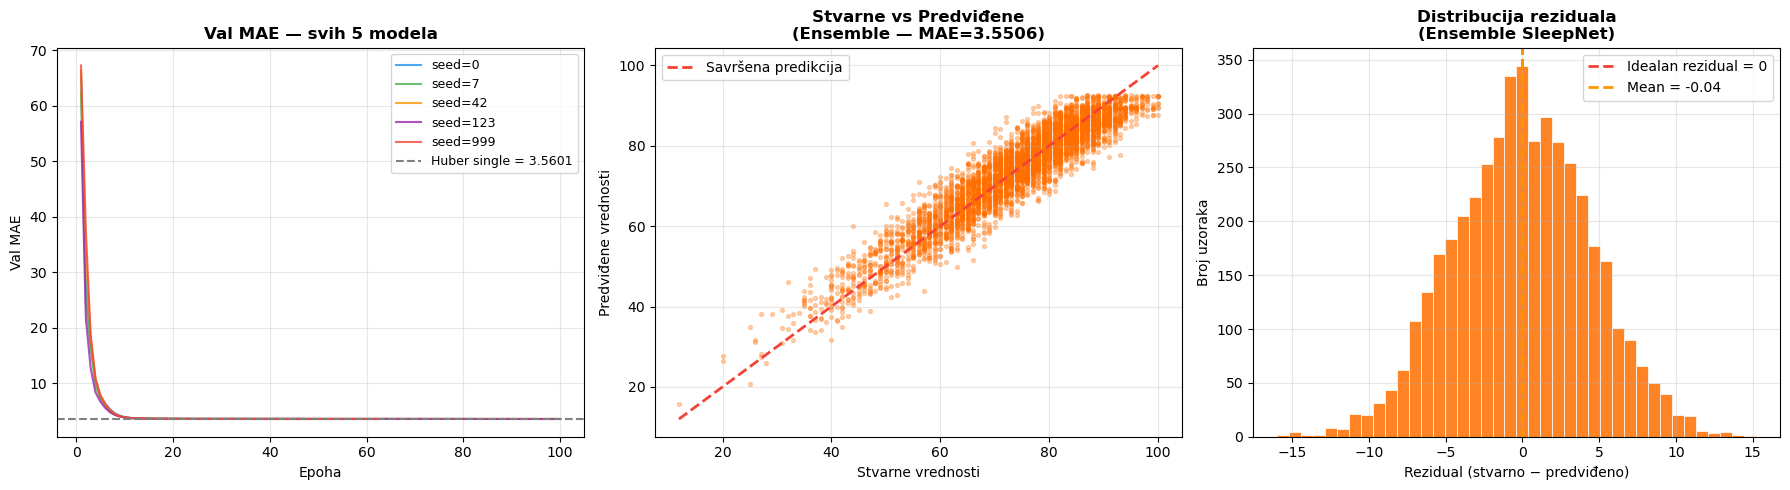

In [60]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Krive treninga svih 5 modela ---
colors_ens = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
for i, (hist, seed) in enumerate(zip(ensemble_histories, SEEDS)):
    ep = range(1, len(hist.history['val_mae']) + 1)
    axes[0].plot(ep, hist.history['val_mae'],
                 color=colors_ens[i], linewidth=1.5,
                 alpha=0.8, label=f'seed={seed}')
axes[0].axhline(y=test_mae_huber, color='gray', linestyle='--',
                linewidth=1.5, label=f'Huber single = {test_mae_huber:.4f}')
axes[0].set_title('Val MAE — svih 5 modela', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('Val MAE')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- Scatter: Stvarne vs Predviđene (ensemble) ---
axes[1].scatter(y_test, y_pred_ensemble, alpha=0.3, s=8, color='#FF6F00')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#F44336', linewidth=2, linestyle='--', label='Savršena predikcija')
axes[1].set_title(f'Stvarne vs Predviđene\n(Ensemble — MAE={test_mae_ensemble:.4f})',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Stvarne vrednosti')
axes[1].set_ylabel('Predviđene vrednosti')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# --- Distribucija reziduala ---
residuals_ens = y_test - y_pred_ensemble
axes[2].hist(residuals_ens, bins=40, color='#FF6F00',
             edgecolor='white', linewidth=0.6, alpha=0.85)
axes[2].axvline(x=0, color='#F44336', linewidth=2,
                linestyle='--', label='Idealan rezidual = 0')
axes[2].axvline(x=residuals_ens.mean(), color='#FF9800', linewidth=2,
                linestyle='--', label=f'Mean = {residuals_ens.mean():.2f}')
axes[2].set_title('Distribucija reziduala\n(Ensemble SleepNet)',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Rezidual (stvarno − predviđeno)')
axes[2].set_ylabel('Broj uzoraka')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [61]:

print("=" * 75)
print("POREĐENJE SVIH MODELA — Test set")
print("=" * 75)
print(f"{'Model':<26} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'Epohe':>7} {'Loss':>8} {'Batch':>6}")
print("-" * 75)
print(f"{'Mean Predictor':<26} {mae_baseline:>8.4f} {rmse_baseline:>8.4f} {r2_baseline:>8.4f} {'—':>7} {'—':>8} {'—':>6}")
print(f"{'Baseline SleepNet':<26} {test_mae:>8.4f} {test_rmse:>8.4f} {test_r2:>8.4f} {len(history.history['loss']):>7} {'MSE':>8} {'256':>6}")
print(f"{'Final SleepNet v1':<26} {test_mae_f:>8.4f} {test_rmse_f:>8.4f} {test_r2_f:>8.4f} {len(history_final.history['loss']):>7} {'MSE':>8} {'256':>6}")
print(f"{'ResNet SleepNet':<26} {test_mae_res:>8.4f} {test_rmse_res:>8.4f} {test_r2_res:>8.4f} {len(history_resnet.history['loss']):>7} {'MSE':>8} {'256':>6}")
print(f"{'Huber SleepNet':<26} {test_mae_huber:>8.4f} {test_rmse_huber:>8.4f} {test_r2_huber:>8.4f} {len(history_huber.history['loss']):>7} {'Huber':>8} {'256':>6}")
print(f"{'AdamW SleepNet':<26} {test_mae_adamw:>8.4f} {test_rmse_adamw:>8.4f} {test_r2_adamw:>8.4f} {len(history_adamw.history['loss']):>7} {'MSE':>8} {'64':>6}")
print(f"{'Ensemble SleepNet (x5)':<26} {test_mae_ensemble:>8.4f} {test_rmse_ensemble:>8.4f} {test_r2_ensemble:>8.4f} {'5×~':>7} {'Huber':>8} {'256':>6}")
print("=" * 75)

all_maes = {
    'Baseline SleepNet':   test_mae,
    'Final SleepNet v1':   test_mae_f,
    'ResNet SleepNet':     test_mae_res,
    'Huber SleepNet':      test_mae_huber,
    'AdamW SleepNet':      test_mae_adamw,
    'Ensemble SleepNet':   test_mae_ensemble,
}
best_name = min(all_maes, key=all_maes.get)
best_val  = all_maes[best_name]
print(f"\nNajbolji model: {best_name}  →  MAE = {best_val:.4f}")
print(f"Poboljšanje vs Baseline SleepNet: {test_mae - best_val:+.4f}  "
      f"({(test_mae - best_val) / test_mae * 100:+.2f}%)")


POREĐENJE SVIH MODELA — Test set
Model                           MAE     RMSE       R²   Epohe     Loss  Batch
---------------------------------------------------------------------------
Mean Predictor              10.3249  12.9558  -0.0001       —        —      —
Baseline SleepNet            3.5552   4.4475   0.8821     100      MSE    256
Final SleepNet v1            3.5725   4.4845   0.8804      36      MSE    256
ResNet SleepNet              3.6330   4.5472   0.8768      39      MSE    256
Huber SleepNet               3.5601   4.4566   0.8817     100    Huber    256
AdamW SleepNet               3.5570   4.4541   0.8818      75      MSE     64
Ensemble SleepNet (x5)       3.5506   4.4473   0.8822     5×~    Huber    256

Najbolji model: Ensemble SleepNet  →  MAE = 3.5506
Poboljšanje vs Baseline SleepNet: +0.0047  (+0.13%)
